In [1]:
from IPython.display import Image
from community_simulator import *
from community_simulator.usertools import *
from community_simulator.visualization import *
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.backends import backend_pdf as bpdf
import distinctipy

import pickle as pkl
import sys
import os

# Get the current working directory (where the script is run from)
current_dir = os.getcwd()

# Get the parent directory
parent_dir = os.path.dirname(os.path.dirname(current_dir))

# Add the parent directory to sys.path
sys.path.append(parent_dir)

params = {'legend.fontsize': 15,
          'figure.figsize': (7, 7),
          'axes.labelsize': 20,
          'axes.titlesize': 20,
          'axes.linewidth': 3,
          'xtick.labelsize':18,
          'ytick.labelsize':18,
          'xtick.labelsize':18,
          'ytick.labelsize':18,
          'svg.fonttype':'none'}
plt.rcParams.update(params)

- **sampling**: Specifies the choice of sampling algorithm. Options include `'Gaussian'`, `'Binary'`, and `'Gamma'`. The default is `'Binary'`.
- **SA**: An array representing the number of species in each specialist family. Here, it is set to 60 species in each of the 3 families.
- **MA**: An array representing the number of resources in each class. Here, it is set to 30 resources in each of the 3 classes.
- **Sgen**: The number of generalist species, which are unbiased in their sampling over all resource classes. The default is 30.
- **muc**: The mean sum of consumption rates, used in all models. The default value is 10.
- **sigc**: The standard deviation of the sum of consumption rates for the Gaussian and Gamma models. The default value is 3.
- **q**: The preference strength of specialist families, where 0 indicates generalist and 1 indicates specialist. The default value is 0.0.
- **c0**: The sum of background consumption rates in the binary model. The default value is 0.0.
- **c1**: The specific consumption rate in the binary model. The default value is 1.0.
- **l**: The leakage fraction. The default value is 0.8.
- **fs**: The fraction of secretion flux with the same resource type. The default value is 0.45.
- **fw**: The fraction of secretion flux to the 'waste' resource. The default value is 0.45.
- **sparsity**: The effective sparsity of the metabolic matrix, which ranges between 0 and 1. The default value is 0.2.
- **waste_type** = index of resource type to designate as "waste".
- **n_wells**: The number of independent wells. The default value is 10.
- **S**: The number of species per well, randomly sampled from the pool of size `Stot = sum(SA) + Sgen`. The default value is 100.
- **food**: The index of the food source when a single resource is supplied externally. The default value is 0.
- **R0_food**: The unperturbed fixed point for the supplied food. The default value is 1000.
- **regulation**: The type of metabolic regulation. Options include `'independent'`, `'energy'`, and `'mass'`. The default is `'independent'`.
- **response**: The type of functional response. Options include `'type I'`, `'type II'`, and `'type III'`. The default is `'type I'`.
- **supply**: The state of resource supply. Options include `'off'`, `'external'`, `'self-renewing'`, and `'predator'`. The default is `'off'`.
---
Params
- **c**: consumer preference matrix c_i,alpha. Default: `c`
- **D**: metabolic matrix D_alphabeta. Default: `D`
- **m**: vector of maintenance costs m_i (or scalar if they are all the same). Default: `1`
- **w**: vector of energy densities w_alpha (or scalar if they are all the same). Default: `1`
- **g**: vector of conversion factors g_i from energy to growth rate (or scalar if they are all the same). Default: `1`
- **l**: vector of leakage fractions l_alpha (or scalar if they are all the same). Default: `0`
- **R0**: equilibrium of intrinsic resource dynamics (in absence of consumers). Default: `R0`
- **tau**: turnover rate for externally supplied resources. Default: `1`
- **r**: rate of self-renewal for self-renewing resources. Default: `1`
- **n**: Hill coefficient for Type III functional response. Default: `2`
- **sigma_max**: maximum uptake rate per resource. Default: `1`
- **nreg**: Hill coefficient for metabolic regulation. Default: `10`

In [2]:
a_default

{'sampling': 'Binary',
 'SA': array([60., 60., 60.]),
 'MA': array([30., 30., 30.]),
 'Sgen': 30,
 'muc': 10,
 'sigc': 3,
 'q': 0.0,
 'c0': 0.0,
 'c1': 1.0,
 'l': 0.8,
 'fs': 0.45,
 'fw': 0.45,
 'sparsity': 0.2,
 'n_wells': 10,
 'S': 100,
 'food': 0,
 'R0_food': 1000,
 'regulation': 'independent',
 'response': 'type I',
 'supply': 'off',
 'metabolism': 'common',
 'rs': 0}

---

## 30 species - Intricate

/home/acs98/Documents/Venturelli-lab/coalescence/community-simulator/community_simulator/__init__.py:426: FutureWarning: The series.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  t, out = IntegrateWell(self,{'y0':N_well.append(R_well).values,'params':params_well},T=T,ns=ns,T0=T0,


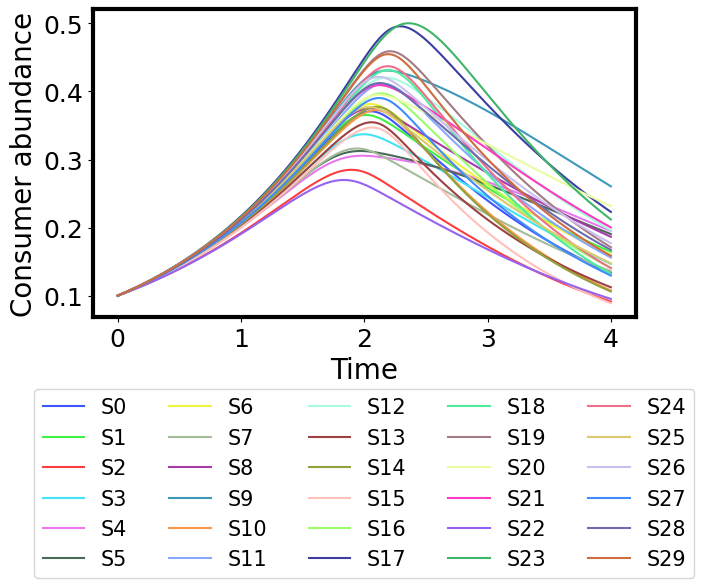

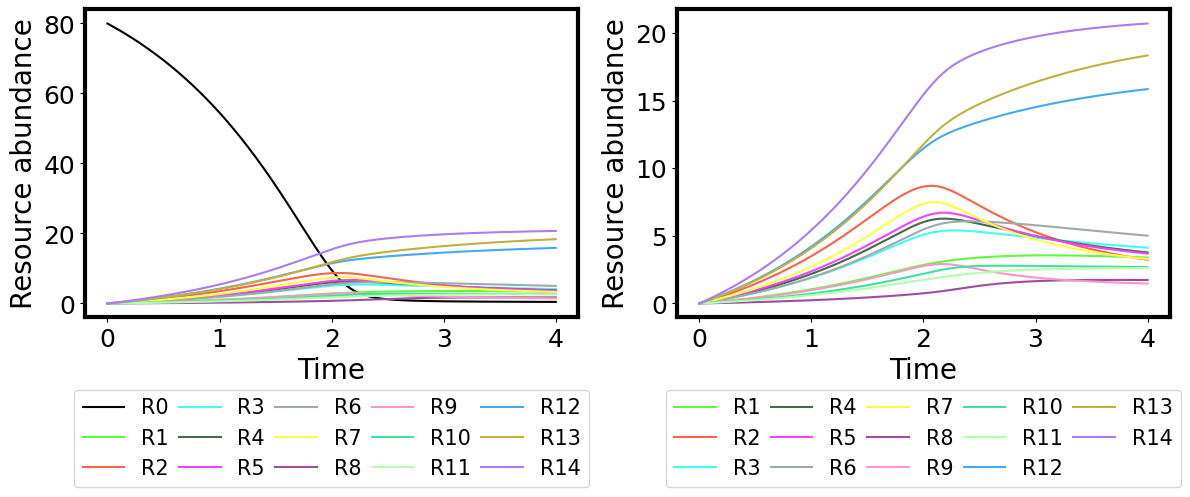

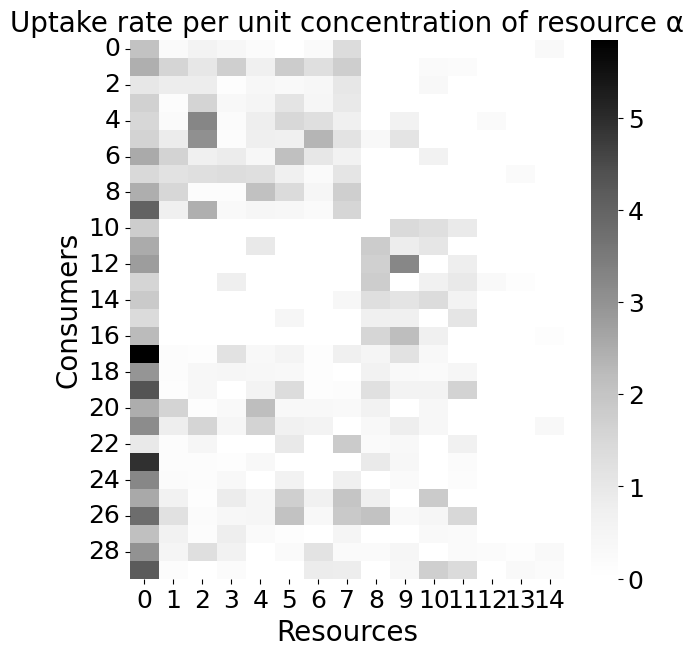

/home/acs98/Documents/Venturelli-lab/coalescence/community-simulator/community_simulator/__init__.py:251: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  y_in = self.N.append(self.R).values


In [ ]:
from IPython.display import Image
from community_simulator import *
from community_simulator.usertools import *
from community_simulator.visualization import *
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.backends import backend_pdf as bpdf
import distinctipy

import pickle as pkl
import sys
import os

# Get the current working directory (where the script is run from)
current_dir = os.getcwd()

# Get the parent directory
parent_dir = os.path.dirname(os.path.dirname(current_dir))

# Add the parent directory to sys.path
sys.path.append(parent_dir)

params = {'legend.fontsize': 15,
          'figure.figsize': (7, 7),
          'axes.labelsize': 20,
          'axes.titlesize': 20,
          'axes.linewidth': 3,
          'xtick.labelsize':18,
          'ytick.labelsize':18,
          'xtick.labelsize':18,
          'ytick.labelsize':18,
          'svg.fonttype':'none'}
plt.rcParams.update(params)

species = 30
resources = 15
experiments = 4000

# np.random.seed(2)
assumptions = a_default.copy()
assumptions.update({'SA':np.array([10,7]),
                    'MA':np.array([8,4,3]),
                    'Sgen':13,
                    'muc':10,
                    'R0_food':80,
                    'n_wells':experiments,
                    'food':0,
                    'S':species,
                    'q':0.85,
                    'l':0.7,
                    'sampling': 'Gamma',
                    'fs':0.55,
                    'fw':0.35,
                    'sparcity':0.7,
                    'response': 'type II',
                    'sigma_max':6,
                    'regulation': 'mass',
                    # 'regulation': 'energy',
                    'nreg':2,
                    'w':np.array([1] + 4*[0.7] + 3*[0.5] + 2*[0.7] + 2*[0.4] + 3*[0.5]),
                    'metabolism':'specific',
                    'rs':0.7,
                    })

init_state = MakeInitialState(assumptions)
params = MakeParams(assumptions)
def dNdt(N,R,params):
    return MakeConsumerDynamics(assumptions)(N,R,params)
def dRdt(N,R,params):
    return MakeResourceDynamics(assumptions)(N,R,params)
dynamics = [dNdt,dRdt]

np.random.seed(0)
MyPlate = Community(init_state,dynamics,params,parallel=True)
all_species = np.ones((species,1))
single_species = np.zeros((species,species))
leave_one_out = np.ones((species,species))
for i in range(MyPlate.N.shape[0]):
    single_species[i,i] = 1
    leave_one_out[i,i] = 0
if species * 2 >= experiments:
    random = np.random.randint(2, size=(species, experiments - 1))
    experiment_matrix = np.concatenate((all_species, random),axis=1) * (3/species)
else:
    random = np.random.randint(2, size=(species, int(experiments - ((species * 2)+1))))
    experiment_matrix = np.concatenate((all_species, single_species, leave_one_out, random),axis=1) * (3/species)
MyPlate.N = MyPlate.N * experiment_matrix

c_iα = pd.read_csv(f'{parent_dir}/community-simulator/consumer_preference_{species}s{resources}r_intricate.csv', index_col=0)
MyPlate.params['c'] = c_iα.values
c_iα.to_csv(f'consumer_preference_{species}s{resources}r_intricate.csv')
D_αβ_17 = pd.read_csv(f'{parent_dir}/community-simulator/resource_conversion_{species}s{resources}r_intricate.csv', index_col=0).values
MyPlate.params['D'][17] = D_αβ_17
for i in range(len(MyPlate.params['D'])):
    MyPlate.params['D'][i][MyPlate.params['D'][i] < 1e-3] = 0
    for j in range(MyPlate.params['D'][i].shape[1]):
        for k in range(MyPlate.params['D'][i].shape[0]):
            if j == k:
                MyPlate.params['D'][i][k,j] = 0
    MyPlate.params['D'][i] = MyPlate.params['D'][i] / MyPlate.params['D'][i].sum(axis=0)
D_αβ = np.array(MyPlate.params['D'].copy())
np.save(f'metabolic_matrix_{species}s{resources}r_intricate.npy', D_αβ)

# D_αβ = np.load(f'{parent_dir}/community-simulator/metabolic_matrix_30s15r.npy')
# MyPlate.params['D'] = [D_αβ[i] for i in range(species)]

# fig,ax = plt.subplots()
# sns.heatmap(MyPlate.N, ax=ax, cmap='Greys')
# ax.set_title('Initial Consumer Populations')
# plt.savefig('initial_consumer_populations_30s.svg', dpi=300)
# plt.show()

# fig,ax = plt.subplots()
# sns.heatmap(MyPlate.R, ax=ax)
# ax.set_title('Initial Resource Abundances')
# plt.show()

# save MyPlate as a pickle file
with open(f'MyPlate_{species}s{resources}r_intricate.pkl', 'wb') as f:
    pkl.dump(MyPlate, f)

t, Ntraj, Rtraj = MyPlate.TestWell(T=4, ns=5000, well_name='W0', show_plots=False)

t = pd.DataFrame(t, columns=['Time'])
Ntraj = pd.DataFrame(Ntraj, columns=MyPlate.N.index.get_level_values(1))
Rtraj = pd.DataFrame(Rtraj, columns=MyPlate.R.index.get_level_values(1))
data = pd.concat([t,Ntraj,Rtraj],axis=1)

colors = distinctipy.get_colors(species, pastel_factor=0.3)
plt.figure(figsize=(7,4))
for i, col in enumerate(Ntraj.columns):
    plt.plot(t, Ntraj[col], color=colors[i % len(colors)], label=col)
plt.xlabel('Time')
plt.ylabel('Consumer abundance')
plt.legend(Ntraj.columns, bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=5)
plt.savefig(f'plots/consumer_abundance_{species}s{resources}r_intricate.svg', dpi=300, bbox_inches='tight')
plt.show()

colors = distinctipy.get_colors(species, pastel_factor=0.3)
plt.figure(figsize=(14,4))
plt.subplot(1,2,1)
for i, col in enumerate(Rtraj.columns):
    color = 'black' if col == 'R0' else colors[i % len(colors)]
    plt.plot(t, Rtraj[col], color=color, label=col)
plt.xlabel('Time')
plt.ylabel('Resource abundance')
plt.legend(Rtraj.columns, bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=5, columnspacing=0.5)
plt.subplot(1,2,2)
for i, col in enumerate(Rtraj.columns):
    if col != 'R0':
        plt.plot(t, Rtraj[col], color=colors[i % len(colors)], label=col)
plt.xlabel('Time')
plt.ylabel('Resource abundance')
plt.legend(Rtraj.columns[Rtraj.columns != 'R0'], bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=5, columnspacing=0.5)
plt.savefig(f'plots/resource_abundance_{species}s{resources}r_intricate.svg', dpi=300, bbox_inches='tight')
plt.show()

#Plot c matrix
fig,ax=plt.subplots()
sns.heatmap(MyPlate.params['c'],
            cmap='Greys',
            # square=True,
            # xticklabels=False,
            # yticklabels=False,
            ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_title('Uptake rate per unit concentration of resource α')
ax.set_xlabel('Resources')
ax.set_ylabel('Consumers')
plt.savefig(f'plots/consumer_preference_{species}s{resources}r_intricate.svg', dpi=300, bbox_inches='tight')
plt.show()

#Plot D matrix
for d in range(len(MyPlate.params['D'])):
    fig,ax=plt.subplots()
    sns.heatmap(MyPlate.params['D'][d],
                cmap='Greys',
                square=True,
                # xticklabels=False,
                # yticklabels=False,
                ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    ax.set_title(f'Species {d}\nFraction of byproducts from\nresource β converted to α')
    ax.set_xlabel('In')
    ax.set_ylabel('Out')
    plt.savefig(f'plots/metabolic_matrix_{species}s{resources}r_{d}_intricate.svg', dpi=300, bbox_inches='tight')
    plt.close()
    # plt.show()

data

## 30 species - simple

/home/acs98/Documents/Venturelli-lab/coalescence/community-simulator/community_simulator/__init__.py:426: FutureWarning: The series.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  t, out = IntegrateWell(self,{'y0':N_well.append(R_well).values,'params':params_well},T=T,ns=ns,T0=T0,


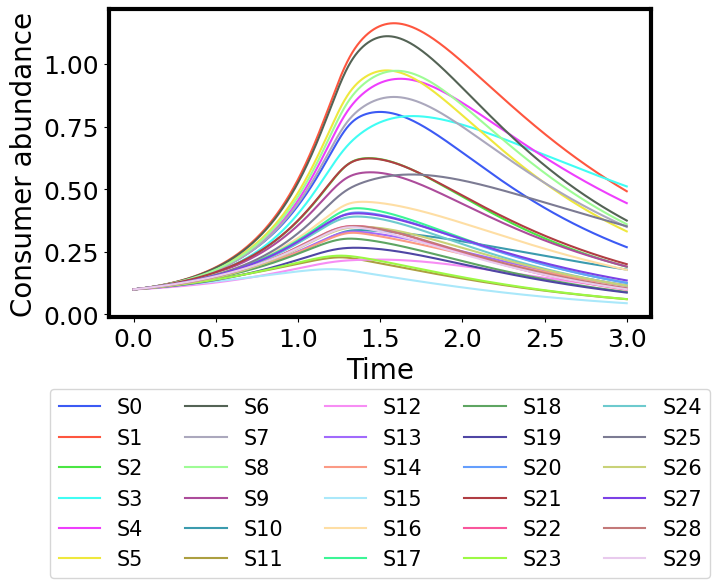

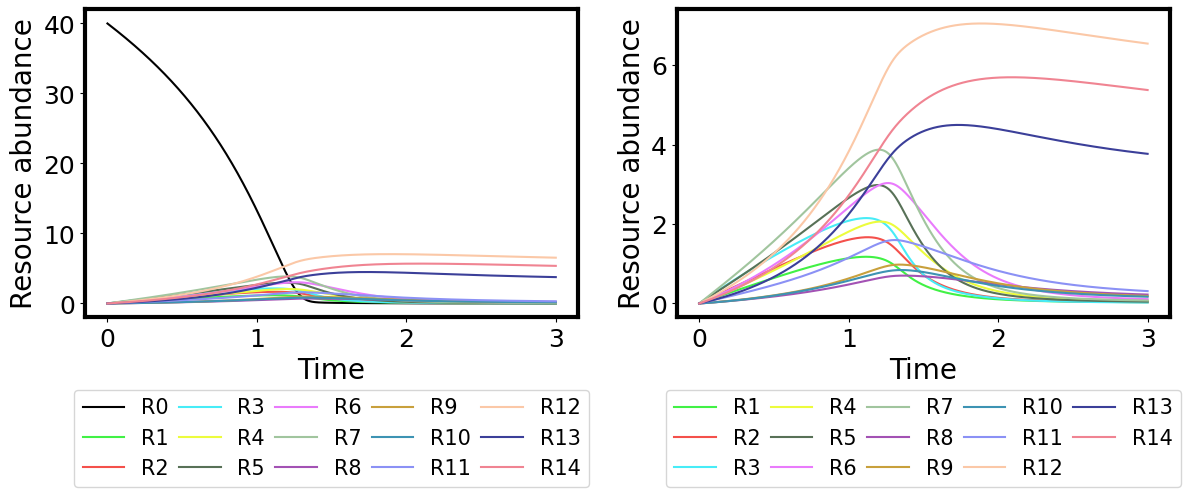

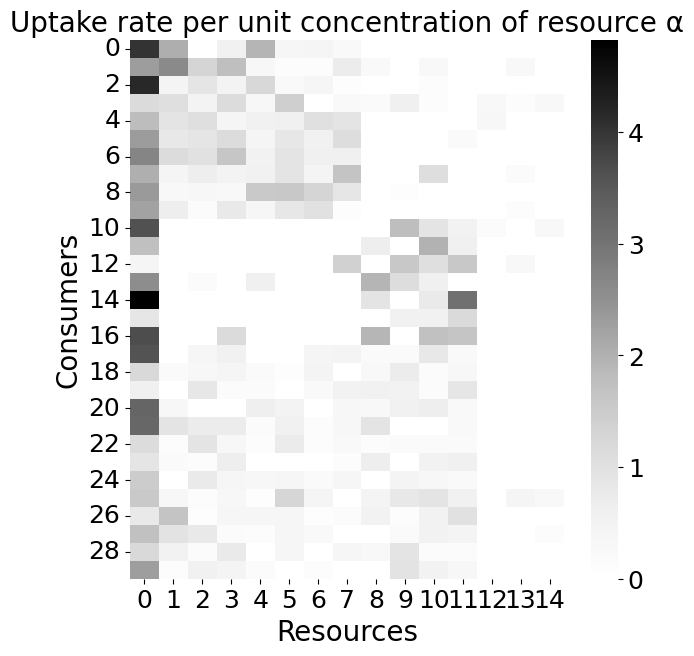

,Time,S0,S1,S2,S3,S4,S5,S6,S7,S8,...,R5,R6,R7,R8,R9,R10,R11,R12,R13,R14
0,0.0000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.0006,0.100044,0.100041,0.100044,0.100036,0.100040,0.100041,0.100042,0.100041,0.100042,...,0.001478,0.000928,0.001792,0.000167,0.000171,0.000150,0.000526,0.001123,0.000521,0.000790
2,0.0012,0.100088,0.100083,0.100089,0.100071,0.100080,0.100083,0.100085,0.100081,0.100083,...,0.002956,0.001857,0.003584,0.000334,0.000342,0.000300,0.001052,0.002248,0.001042,0.001580
3,0.0018,0.100133,0.100125,0.100133,0.100107,0.100120,0.100125,0.100127,0.100122,0.100125,...,0.004434,0.002786,0.005376,0.000502,0.000513,0.000450,0.001577,0.003372,0.001564,0.002371
4,0.0024,0.100177,0.100167,0.100178,0.100143,0.100160,0.100167,0.100170,0.100163,0.100167,...,0.005911,0.003715,0.007168,0.000669,0.000684,0.000601,0.002103,0.004498,0.002086,0.003162
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,2.9976,0.269378,0.493120,0.190744,0.512113,0.445452,0.332548,0.375961,0.350469,0.361185,...,0.045925,0.109858,0.075405,0.224691,0.188259,0.170131,0.312085,6.543193,3.768448,5.374475
4996,2.9982,0.269227,0.492887,0.190635,0.511970,0.445263,0.332361,0.375749,0.350293,0.360985,...,0.045902,0.109798,0.075370,0.224620,0.188185,0.170067,0.311962,6.542895,3.768189,5.374199
4997,2.9988,0.269076,0.492654,0.190526,0.511827,0.445073,0.332174,0.375536,0.350117,0.360785,...,0.045879,0.109738,0.075336,0.224549,0.188112,0.170002,0.311839,6.542598,3.767930,5.373923
4998,2.9994,0.268924,0.492422,0.190418,0.511684,0.444883,0.331988,0.375324,0.349941,0.360585,...,0.045855,0.109678,0.075302,0.224479,0.188038,0.169937,0.311716,6.542300,3.767671,5.373647


In [4]:
from IPython.display import Image
from community_simulator import *
from community_simulator.usertools import *
from community_simulator.visualization import *
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.backends import backend_pdf as bpdf
import distinctipy

import pickle as pkl
import sys
import os

# Get the current working directory (where the script is run from)
current_dir = os.getcwd()

# Get the parent directory
parent_dir = os.path.dirname(os.path.dirname(current_dir))

# Add the parent directory to sys.path
sys.path.append(parent_dir)

params = {'legend.fontsize': 15,
          'figure.figsize': (7, 7),
          'axes.labelsize': 20,
          'axes.titlesize': 20,
          'axes.linewidth': 3,
          'xtick.labelsize':18,
          'ytick.labelsize':18,
          'xtick.labelsize':18,
          'ytick.labelsize':18,
          'svg.fonttype':'none'}
plt.rcParams.update(params)

species = 30
resources = 15
experiments = 4000

# np.random.seed(2)
assumptions = a_default.copy()
assumptions.update({'SA':np.array([10,7]),
                    'MA':np.array([8,4,3]),
                    'Sgen':13,
                    'muc':8,
                    'sigc': 2,
                    'R0_food':40,
                    'n_wells':experiments,
                    'food':0,
                    'S':species,
                    'q':0.85,
                    'l':0.7,
                    'sampling': 'Gamma',
                    'fs':0.75,
                    'fw':0.15,
                    'sparcity':0.7,
                    'response': 'type II',
                    'sigma_max':6,
                    # 'regulation': 'mass',
                    # 'regulation': 'energy',
                    # 'nreg':2,
                    'w':np.array([1] + 4*[0.7] + 3*[0.5] + 2*[0.7] + 2*[0.4] + 3*[0.5]),
                    'metabolism':'specific',
                    'rs':0.7,
                    })

init_state = MakeInitialState(assumptions)
params = MakeParams(assumptions)
def dNdt(N,R,params):
    return MakeConsumerDynamics(assumptions)(N,R,params)
def dRdt(N,R,params):
    return MakeResourceDynamics(assumptions)(N,R,params)
dynamics = [dNdt,dRdt]

np.random.seed(1234)
MyPlate = Community(init_state,dynamics,params,parallel=True)
all_species = np.ones((species,1))
single_species = np.zeros((species,species))
leave_one_out = np.ones((species,species))
for i in range(MyPlate.N.shape[0]):
    single_species[i,i] = 1
    leave_one_out[i,i] = 0
if species * 2 >= experiments:
    random = np.random.randint(2, size=(species, experiments - 1))
    experiment_matrix = np.concatenate((all_species, random),axis=1) * (3/species)
else:
    random = np.random.randint(2, size=(species, int(experiments - ((species * 2)+1))))
    experiment_matrix = np.concatenate((all_species, single_species, leave_one_out, random),axis=1) * (3/species)
MyPlate.N = MyPlate.N * experiment_matrix

c_iα = pd.read_csv(f'{parent_dir}/community-simulator/consumer_preference_{species}s{resources}r_simple.csv', index_col=0)
MyPlate.params['c'] = c_iα.values
c_iα.to_csv(f'consumer_preference_{species}s{resources}r_simple.csv')
D_αβ_27 = pd.read_csv(f'{parent_dir}/community-simulator/resource_conversion_{species}s{resources}r_simple.csv', index_col=0).values
MyPlate.params['D'][27] = D_αβ_27
for i in range(len(MyPlate.params['D'])):
    MyPlate.params['D'][i][MyPlate.params['D'][i] < 1e-3] = 0
    for j in range(MyPlate.params['D'][i].shape[1]):
        for k in range(MyPlate.params['D'][i].shape[0]):
            if j == k:
                MyPlate.params['D'][i][k,j] = 0
    MyPlate.params['D'][i] = MyPlate.params['D'][i] / MyPlate.params['D'][i].sum(axis=0)
D_αβ = np.array(MyPlate.params['D'].copy())
np.save(f'metabolic_matrix_{species}s{resources}r_simple.npy', D_αβ)

# D_αβ = np.load(f'{parent_dir}/community-simulator/metabolic_matrix_30s15r.npy')
# MyPlate.params['D'] = [D_αβ[i] for i in range(species)]

# fig,ax = plt.subplots()
# sns.heatmap(MyPlate.N, ax=ax, cmap='Greys')
# ax.set_title('Initial Consumer Populations')
# plt.savefig('initial_consumer_populations_30s.svg', dpi=300)
# plt.show()

# fig,ax = plt.subplots()
# sns.heatmap(MyPlate.R, ax=ax)
# ax.set_title('Initial Resource Abundances')
# plt.show()

# save MyPlate as a pickle file
with open(f'MyPlate_{species}s{resources}r_simple.pkl', 'wb') as f:
    pkl.dump(MyPlate, f)
    
t, Ntraj, Rtraj = MyPlate.TestWell(T=3, ns=5000, well_name='W0', show_plots=False)

t = pd.DataFrame(t, columns=['Time'])
Ntraj = pd.DataFrame(Ntraj, columns=MyPlate.N.index.get_level_values(1))
Rtraj = pd.DataFrame(Rtraj, columns=MyPlate.R.index.get_level_values(1))
data = pd.concat([t,Ntraj,Rtraj],axis=1)

colors = distinctipy.get_colors(species, pastel_factor=0.3)
plt.figure(figsize=(7,4))
for i, col in enumerate(Ntraj.columns):
    plt.plot(t, Ntraj[col], color=colors[i % len(colors)], label=col)
plt.xlabel('Time')
plt.ylabel('Consumer abundance')
plt.legend(Ntraj.columns, bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=5)
plt.savefig(f'plots/consumer_abundance_{species}s{resources}r_simple.svg', dpi=300, bbox_inches='tight')
plt.show()

colors = distinctipy.get_colors(species, pastel_factor=0.3)
plt.figure(figsize=(14,4))
plt.subplot(1,2,1)
for i, col in enumerate(Rtraj.columns):
    color = 'black' if col == 'R0' else colors[i % len(colors)]
    plt.plot(t, Rtraj[col], color=color, label=col)
plt.xlabel('Time')
plt.ylabel('Resource abundance')
plt.legend(Rtraj.columns, bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=5, columnspacing=0.5)
plt.subplot(1,2,2)
for i, col in enumerate(Rtraj.columns):
    if col != 'R0':
        plt.plot(t, Rtraj[col], color=colors[i % len(colors)], label=col)
plt.xlabel('Time')
plt.ylabel('Resource abundance')
plt.legend(Rtraj.columns[Rtraj.columns != 'R0'], bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=5, columnspacing=0.5)
plt.savefig(f'plots/resource_abundance_{species}s{resources}r_simple.svg', dpi=300, bbox_inches='tight')
plt.show()

#Plot c matrix
fig,ax=plt.subplots()
sns.heatmap(MyPlate.params['c'],
            cmap='Greys',
            # square=True,
            # xticklabels=False,
            # yticklabels=False,
            ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_title('Uptake rate per unit concentration of resource α')
ax.set_xlabel('Resources')
ax.set_ylabel('Consumers')
plt.savefig(f'plots/consumer_preference_{species}s{resources}r_simple.svg', dpi=300, bbox_inches='tight')
plt.show()

#Plot D matrix
for d in range(len(MyPlate.params['D'])):
    fig,ax=plt.subplots()
    sns.heatmap(MyPlate.params['D'][d],
                cmap='Greys',
                square=True,
                # xticklabels=False,
                # yticklabels=False,
                ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    ax.set_title(f'Species {d}\nFraction of byproducts from\nresource β converted to α')
    ax.set_xlabel('In')
    ax.set_ylabel('Out')
    plt.savefig(f'plots/metabolic_matrix_{species}s{resources}r_{d}_simple.svg', dpi=300, bbox_inches='tight')
    plt.close()
    # plt.show()

data

## 30 species - base

/home/acs98/Documents/Venturelli-lab/coalescence/community-simulator/community_simulator/__init__.py:426: FutureWarning: The series.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  t, out = IntegrateWell(self,{'y0':N_well.append(R_well).values,'params':params_well},T=T,ns=ns,T0=T0,


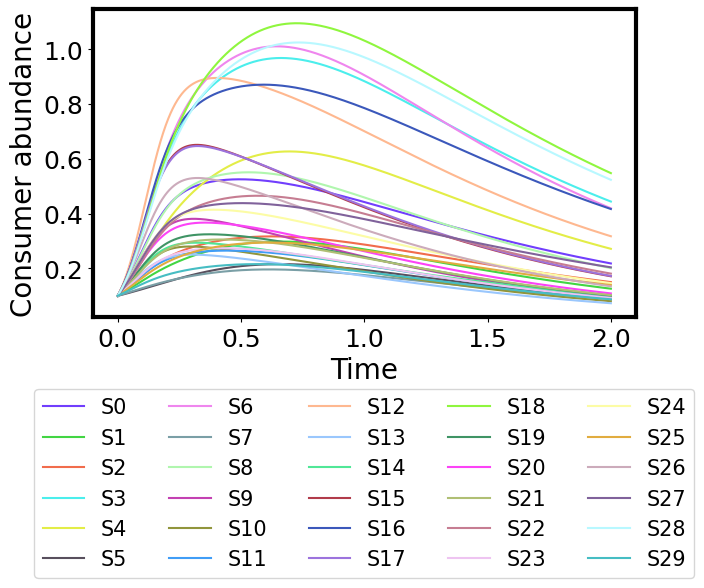

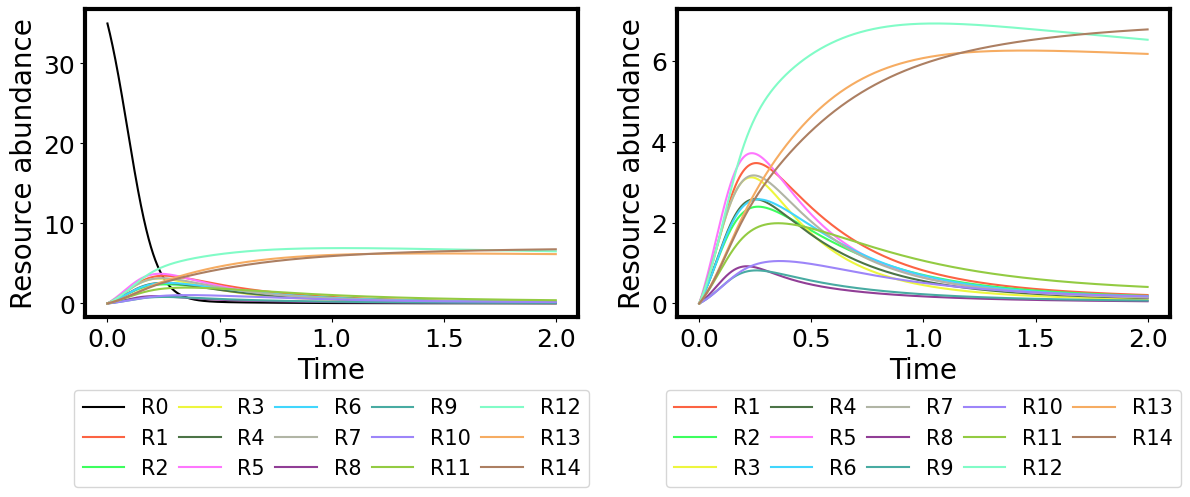

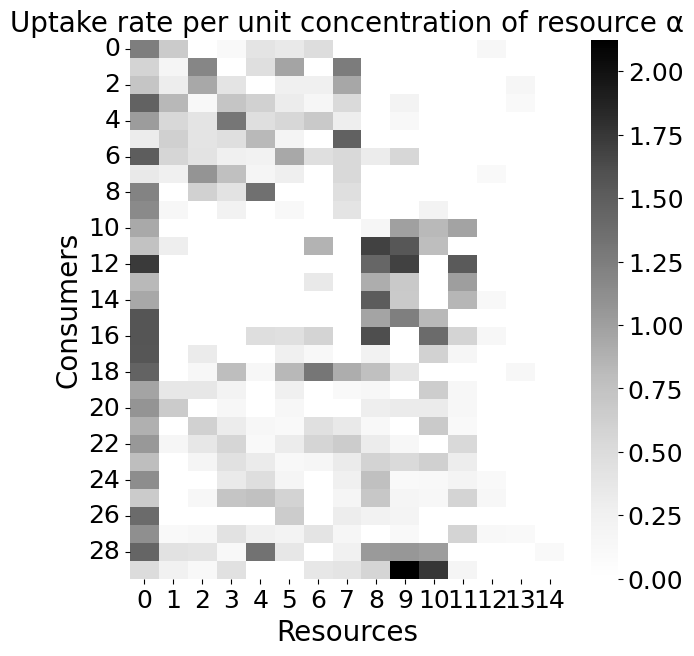

,Time,S0,S1,S2,S3,S4,S5,S6,S7,S8,...,R5,R6,R7,R8,R9,R10,R11,R12,R13,R14
0,0.0000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.0004,0.100483,0.100201,0.100266,0.100578,0.100391,0.100090,0.100594,0.100110,0.100469,...,0.006817,0.004258,0.005984,0.001641,0.001166,0.001174,0.002787,0.005130,0.002838,0.002724
2,0.0008,0.100968,0.100402,0.100533,0.101158,0.100783,0.100180,0.101191,0.100219,0.100940,...,0.013654,0.008530,0.011984,0.003289,0.002338,0.002352,0.005582,0.010280,0.005686,0.005458
3,0.0012,0.101455,0.100604,0.100801,0.101742,0.101177,0.100270,0.101790,0.100329,0.101412,...,0.020513,0.012816,0.018000,0.004944,0.003514,0.003535,0.008384,0.015449,0.008543,0.008201
4,0.0016,0.101943,0.100806,0.101068,0.102328,0.101572,0.100360,0.102393,0.100439,0.101886,...,0.027392,0.017116,0.024031,0.006605,0.004694,0.004722,0.011193,0.020639,0.011410,0.010954
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,1.9984,0.218408,0.126155,0.150335,0.444661,0.271909,0.090357,0.420120,0.087822,0.201371,...,0.152008,0.161916,0.154225,0.054894,0.072482,0.178342,0.409169,6.520709,6.170085,6.775016
4996,1.9988,0.218340,0.126111,0.150291,0.444520,0.271814,0.090325,0.419972,0.087795,0.201298,...,0.151955,0.161854,0.154171,0.054878,0.072461,0.178294,0.409065,6.520522,6.169999,6.775147
4997,1.9992,0.218272,0.126066,0.150246,0.444379,0.271719,0.090293,0.419824,0.087767,0.201225,...,0.151902,0.161793,0.154117,0.054862,0.072439,0.178246,0.408962,6.520335,6.169912,6.775277
4998,1.9996,0.218203,0.126022,0.150201,0.444238,0.271624,0.090261,0.419676,0.087739,0.201151,...,0.151848,0.161731,0.154063,0.054846,0.072418,0.178198,0.408859,6.520148,6.169825,6.775408


In [5]:
from IPython.display import Image
from community_simulator import *
from community_simulator.usertools import *
from community_simulator.visualization import *
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.backends import backend_pdf as bpdf
import distinctipy

import pickle as pkl
import sys
import os

# Get the current working directory (where the script is run from)
current_dir = os.getcwd()

# Get the parent directory
parent_dir = os.path.dirname(os.path.dirname(current_dir))

# Add the parent directory to sys.path
sys.path.append(parent_dir)

params = {'legend.fontsize': 15,
          'figure.figsize': (7, 7),
          'axes.labelsize': 20,
          'axes.titlesize': 20,
          'axes.linewidth': 3,
          'xtick.labelsize':18,
          'ytick.labelsize':18,
          'xtick.labelsize':18,
          'ytick.labelsize':18,
          'svg.fonttype':'none'}
plt.rcParams.update(params)

species = 30
resources = 15
experiments = 4000

# np.random.seed(2)
assumptions = a_default.copy()
assumptions.update({'SA':np.array([10,7]),
                    'MA':np.array([8,4,3]),
                    'Sgen':13,
                    'muc':5,
                    'sigc': 1.5,
                    'R0_food':35,
                    'n_wells':experiments,
                    'food':0,
                    'S':species,
                    'q':0.85,
                    'l':0.7,
                    'sampling': 'Gamma',
                    'fs':0.7,
                    'fw':0.2,
                    'sparcity':0.7,
                    # 'response': 'type II',
                    # 'sigma_max':6,
                    # 'regulation': 'mass',
                    # 'regulation': 'energy',
                    # 'nreg':2,
                    'w':np.array([1] + 4*[0.7] + 3*[0.5] + 2*[0.7] + 2*[0.4] + 3*[0.5]),
                    'metabolism':'specific',
                    'rs':0.7,
                    })

init_state = MakeInitialState(assumptions)
params = MakeParams(assumptions)
def dNdt(N,R,params):
    return MakeConsumerDynamics(assumptions)(N,R,params)
def dRdt(N,R,params):
    return MakeResourceDynamics(assumptions)(N,R,params)
dynamics = [dNdt,dRdt]

np.random.seed(1234)
MyPlate = Community(init_state,dynamics,params,parallel=True)
all_species = np.ones((species,1))
single_species = np.zeros((species,species))
leave_one_out = np.ones((species,species))
for i in range(MyPlate.N.shape[0]):
    single_species[i,i] = 1
    leave_one_out[i,i] = 0
if species * 2 >= experiments:
    random = np.random.randint(2, size=(species, experiments - 1))
    experiment_matrix = np.concatenate((all_species, random),axis=1) * (3/species)
else:
    random = np.random.randint(2, size=(species, int(experiments - ((species * 2)+1))))
    experiment_matrix = np.concatenate((all_species, single_species, leave_one_out, random),axis=1) * (3/species)
MyPlate.N = MyPlate.N * experiment_matrix

c_iα = pd.read_csv(f'{parent_dir}/community-simulator/consumer_preference_{species}s{resources}r_base.csv', index_col=0)
MyPlate.params['c'] = c_iα.values
c_iα.to_csv(f'consumer_preference_{species}s{resources}r_base.csv')
D_αβ_22 = pd.read_csv(f'{parent_dir}/community-simulator/resource_conversion_{species}s{resources}r_simple.csv', index_col=0).values
MyPlate.params['D'][22] = D_αβ_22
for i in range(len(MyPlate.params['D'])):
    MyPlate.params['D'][i][MyPlate.params['D'][i] < 1e-3] = 0
    for j in range(MyPlate.params['D'][i].shape[1]):
        for k in range(MyPlate.params['D'][i].shape[0]):
            if j == k:
                MyPlate.params['D'][i][k,j] = 0
    MyPlate.params['D'][i] = MyPlate.params['D'][i] / MyPlate.params['D'][i].sum(axis=0)
D_αβ = np.array(MyPlate.params['D'].copy())
np.save(f'metabolic_matrix_{species}s{resources}r_base.npy', D_αβ)

# D_αβ = np.load(f'{parent_dir}/community-simulator/metabolic_matrix_30s15r.npy')
# MyPlate.params['D'] = [D_αβ[i] for i in range(species)]

# fig,ax = plt.subplots()
# sns.heatmap(MyPlate.N, ax=ax, cmap='Greys')
# ax.set_title('Initial Consumer Populations')
# plt.savefig('initial_consumer_populations_30s.svg', dpi=300)
# plt.show()

# fig,ax = plt.subplots()
# sns.heatmap(MyPlate.R, ax=ax)
# ax.set_title('Initial Resource Abundances')
# plt.show()

# save MyPlate as a pickle file
with open(f'MyPlate_{species}s{resources}r_base.pkl', 'wb') as f:
    pkl.dump(MyPlate, f)

t, Ntraj, Rtraj = MyPlate.TestWell(T=2, ns=5000, well_name='W0', show_plots=False)

t = pd.DataFrame(t, columns=['Time'])
Ntraj = pd.DataFrame(Ntraj, columns=MyPlate.N.index.get_level_values(1))
Rtraj = pd.DataFrame(Rtraj, columns=MyPlate.R.index.get_level_values(1))
data = pd.concat([t,Ntraj,Rtraj],axis=1)

colors = distinctipy.get_colors(species, pastel_factor=0.3)
plt.figure(figsize=(7,4))
for i, col in enumerate(Ntraj.columns):
    plt.plot(t, Ntraj[col], color=colors[i % len(colors)], label=col)
plt.xlabel('Time')
plt.ylabel('Consumer abundance')
plt.legend(Ntraj.columns, bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=5)
plt.savefig(f'plots/consumer_abundance_{species}s{resources}r_base.png', dpi=300, bbox_inches='tight')
plt.show()

colors = distinctipy.get_colors(species, pastel_factor=0.3)
plt.figure(figsize=(14,4))
plt.subplot(1,2,1)
for i, col in enumerate(Rtraj.columns):
    color = 'black' if col == 'R0' else colors[i % len(colors)]
    plt.plot(t, Rtraj[col], color=color, label=col)
plt.xlabel('Time')
plt.ylabel('Resource abundance')
plt.legend(Rtraj.columns, bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=5, columnspacing=0.5)
plt.subplot(1,2,2)
for i, col in enumerate(Rtraj.columns):
    if col != 'R0':
        plt.plot(t, Rtraj[col], color=colors[i % len(colors)], label=col)
plt.xlabel('Time')
plt.ylabel('Resource abundance')
plt.legend(Rtraj.columns[Rtraj.columns != 'R0'], bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=5, columnspacing=0.5)
plt.savefig(f'plots/resource_abundance_{species}s{resources}r_base.png', dpi=300, bbox_inches='tight')
plt.show()

#Plot c matrix
fig,ax=plt.subplots()
sns.heatmap(MyPlate.params['c'],
            cmap='Greys',
            # square=True,
            # xticklabels=False,
            # yticklabels=False,
            ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_title('Uptake rate per unit concentration of resource α')
ax.set_xlabel('Resources')
ax.set_ylabel('Consumers')
plt.savefig(f'plots/consumer_preference_{species}s{resources}r_base.svg', dpi=300, bbox_inches='tight')
plt.show()

#Plot D matrix
for d in range(len(MyPlate.params['D'])):
    fig,ax=plt.subplots()
    sns.heatmap(MyPlate.params['D'][d],
                cmap='Greys',
                square=True,
                # xticklabels=False,
                # yticklabels=False,
                ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    ax.set_title(f'Species {d}\nFraction of byproducts from\nresource β converted to α')
    ax.set_xlabel('In')
    ax.set_ylabel('Out')
    plt.savefig(f'plots/metabolic_matrix_{species}s{resources}r_{d}_base.svg', dpi=300, bbox_inches='tight')
    plt.close()
    # plt.show()

data

---

## 12 species - Intricate

/home/acs98/Documents/Venturelli-lab/coalescence/community-simulator/community_simulator/__init__.py:426: FutureWarning: The series.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  t, out = IntegrateWell(self,{'y0':N_well.append(R_well).values,'params':params_well},T=T,ns=ns,T0=T0,


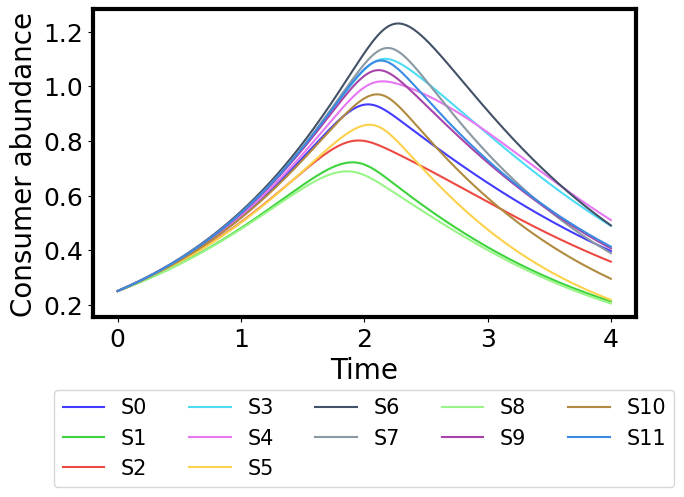

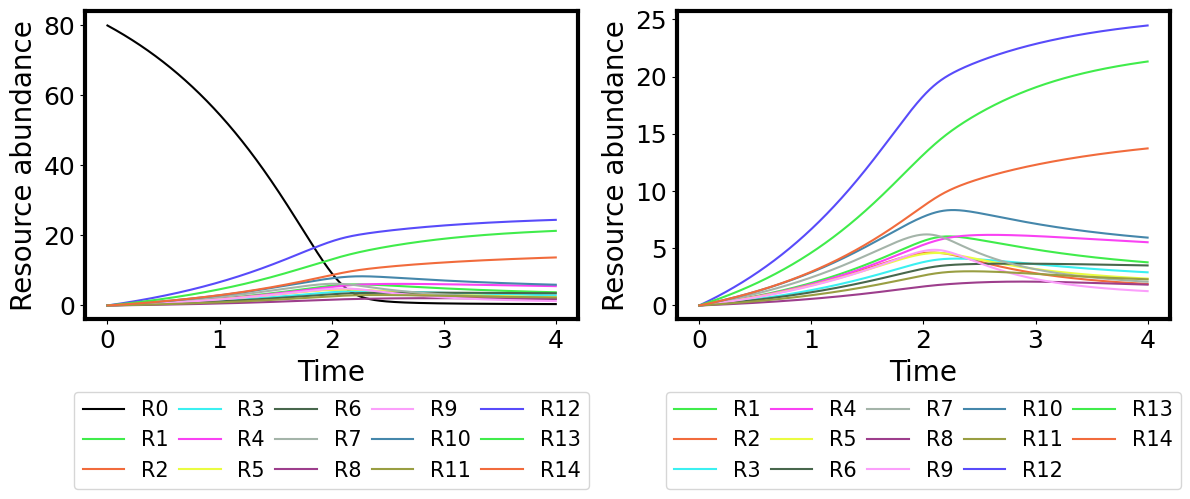

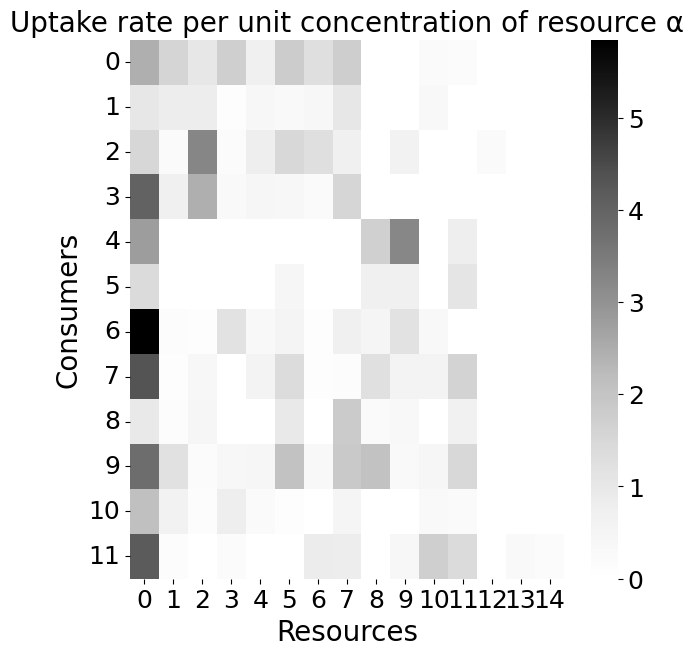

,Time,S0,S1,S2,S3,S4,S5,S6,S7,S8,...,R5,R6,R7,R8,R9,R10,R11,R12,R13,R14
0,0.000000,0.250000,0.250000,0.250000,0.250000,0.250000,0.250000,0.250000,0.250000,0.250000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000800,0.250149,0.250135,0.250143,0.250154,0.250151,0.250142,0.250156,0.250154,0.250134,...,0.000980,0.000635,0.001344,0.000312,0.000930,0.001605,0.000482,0.003675,0.002516,0.001596
2,0.001600,0.250299,0.250270,0.250286,0.250307,0.250301,0.250284,0.250311,0.250308,0.250268,...,0.001961,0.001271,0.002690,0.000624,0.001861,0.003210,0.000965,0.007351,0.005034,0.003193
3,0.002400,0.250448,0.250405,0.250429,0.250461,0.250452,0.250426,0.250467,0.250462,0.250402,...,0.002942,0.001907,0.004036,0.000936,0.002792,0.004817,0.001448,0.011030,0.007553,0.004791
4,0.003201,0.250598,0.250541,0.250573,0.250615,0.250603,0.250568,0.250623,0.250616,0.250536,...,0.003924,0.002543,0.005382,0.001248,0.003724,0.006424,0.001931,0.014711,0.010074,0.006390
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,3.996799,0.396955,0.212307,0.358071,0.489829,0.510767,0.218121,0.491486,0.389421,0.204720,...,2.349924,3.498794,2.075106,1.822538,1.254894,5.933153,2.288645,24.463195,21.314393,13.721689
4996,3.997600,0.396790,0.212190,0.357924,0.489605,0.510536,0.217981,0.491230,0.389209,0.204603,...,2.349515,3.498649,2.074645,1.822305,1.254490,5.932486,2.288364,24.464015,21.315478,13.722498
4997,3.998400,0.396626,0.212073,0.357778,0.489381,0.510306,0.217842,0.490974,0.388996,0.204487,...,2.349106,3.498504,2.074184,1.822073,1.254086,5.931819,2.288083,24.464834,21.316563,13.723307
4998,3.999200,0.396462,0.211956,0.357631,0.489157,0.510076,0.217703,0.490717,0.388784,0.204371,...,2.348698,3.498359,2.073723,1.821840,1.253682,5.931153,2.287802,24.465653,21.317646,13.724115


In [6]:
from IPython.display import Image
from community_simulator import *
from community_simulator.usertools import *
from community_simulator.visualization import *
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.backends import backend_pdf as bpdf
import distinctipy

import pickle as pkl
import sys
import os

# Get the current working directory (where the script is run from)
current_dir = os.getcwd()

# Get the parent directory
parent_dir = os.path.dirname(os.path.dirname(current_dir))

# Add the parent directory to sys.path
sys.path.append(parent_dir)

params = {'legend.fontsize': 15,
          'figure.figsize': (7, 7),
          'axes.labelsize': 20,
          'axes.titlesize': 20,
          'axes.linewidth': 3,
          'xtick.labelsize':18,
          'ytick.labelsize':18,
          'xtick.labelsize':18,
          'ytick.labelsize':18,
          'svg.fonttype':'none'}
plt.rcParams.update(params)

species = 12
resources = 15
experiments = 4000

# np.random.seed(2)
assumptions = a_default.copy()
assumptions.update({'SA':np.array([4,2]),
                    'MA':np.array([8,4,3]),
                    'Sgen':6,
                    'muc':10,
                    'R0_food':80,
                    'n_wells':experiments,
                    'food':0,
                    'S':species,
                    'q':0.85,
                    'l':0.7,
                    'sampling': 'Gamma',
                    'fs':0.55,
                    'fw':0.35,
                    'sparcity':0.7,
                    'response': 'type II',
                    'sigma_max':6,
                    'regulation': 'mass',
                    # 'regulation': 'energy',
                    'nreg':2,
                    'w':np.array([1] + 4*[0.7] + 3*[0.5] + 2*[0.7] + 2*[0.4] + 3*[0.5]),
                    'metabolism':'specific',
                    'rs':0.7,
                    })

init_state = MakeInitialState(assumptions)
params = MakeParams(assumptions)
def dNdt(N,R,params):
    return MakeConsumerDynamics(assumptions)(N,R,params)
def dRdt(N,R,params):
    return MakeResourceDynamics(assumptions)(N,R,params)
dynamics = [dNdt,dRdt]

np.random.seed(0)
MyPlate = Community(init_state,dynamics,params,parallel=True)
all_species = np.ones((species,1))
single_species = np.zeros((species,species))
leave_one_out = np.ones((species,species))
for i in range(MyPlate.N.shape[0]):
    single_species[i,i] = 1
    leave_one_out[i,i] = 0
if species * 2 >= experiments:
    random = np.random.randint(2, size=(species, experiments - 1))
    experiment_matrix = np.concatenate((all_species, random),axis=1) * (3/species)
else:
    random = np.random.randint(2, size=(species, int(experiments - ((species * 2)+1))))
    experiment_matrix = np.concatenate((all_species, single_species, leave_one_out, random),axis=1) * (3/species)
MyPlate.N = MyPlate.N * experiment_matrix

c_iα = pd.read_csv(f'{parent_dir}/community-simulator/consumer_preference_{species}s{resources}r_intricate.csv', index_col=0)
MyPlate.params['c'] = c_iα.values
c_iα.to_csv(f'consumer_preference_{species}s{resources}r_intricate.csv')
D_αβ_6 = pd.read_csv(f'{parent_dir}/community-simulator/resource_conversion_{species}s{resources}r_intricate.csv', index_col=0).values
MyPlate.params['D'][6] = D_αβ_6
for i in range(len(MyPlate.params['D'])):
    MyPlate.params['D'][i][MyPlate.params['D'][i] < 1e-3] = 0
    for j in range(MyPlate.params['D'][i].shape[1]):
        for k in range(MyPlate.params['D'][i].shape[0]):
            if j == k:
                MyPlate.params['D'][i][k,j] = 0
    MyPlate.params['D'][i] = MyPlate.params['D'][i] / MyPlate.params['D'][i].sum(axis=0)
D_αβ = np.array(MyPlate.params['D'].copy())
np.save(f'metabolic_matrix_{species}s{resources}r_intricate.npy', D_αβ)

# D_αβ = np.load(f'{parent_dir}/community-simulator/metabolic_matrix_30s15r.npy')
# MyPlate.params['D'] = [D_αβ[i] for i in range(species)]

# fig,ax = plt.subplots()
# sns.heatmap(MyPlate.N, ax=ax, cmap='Greys')
# ax.set_title('Initial Consumer Populations')
# plt.savefig('initial_consumer_populations_30s.svg', dpi=300)
# plt.show()

# fig,ax = plt.subplots()
# sns.heatmap(MyPlate.R, ax=ax)
# ax.set_title('Initial Resource Abundances')
# plt.show()

# save MyPlate as a pickle file
with open(f'MyPlate_{species}s{resources}r_intricate.pkl', 'wb') as f:
    pkl.dump(MyPlate, f)

t, Ntraj, Rtraj = MyPlate.TestWell(T=4, ns=5000, well_name='W0', show_plots=False)

t = pd.DataFrame(t, columns=['Time'])
Ntraj = pd.DataFrame(Ntraj, columns=MyPlate.N.index.get_level_values(1))
Rtraj = pd.DataFrame(Rtraj, columns=MyPlate.R.index.get_level_values(1))
data = pd.concat([t,Ntraj,Rtraj],axis=1)

colors = distinctipy.get_colors(species, pastel_factor=0.3)
plt.figure(figsize=(7,4))
for i, col in enumerate(Ntraj.columns):
    plt.plot(t, Ntraj[col], color=colors[i % len(colors)], label=col)
plt.xlabel('Time')
plt.ylabel('Consumer abundance')
plt.legend(Ntraj.columns, bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=5)
plt.savefig(f'plots/consumer_abundance_{species}s{resources}r_intricate.svg', dpi=300, bbox_inches='tight')
plt.show()

colors = distinctipy.get_colors(species, pastel_factor=0.3)
plt.figure(figsize=(14,4))
plt.subplot(1,2,1)
for i, col in enumerate(Rtraj.columns):
    color = 'black' if col == 'R0' else colors[i % len(colors)]
    plt.plot(t, Rtraj[col], color=color, label=col)
plt.xlabel('Time')
plt.ylabel('Resource abundance')
plt.legend(Rtraj.columns, bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=5, columnspacing=0.5)
plt.subplot(1,2,2)
for i, col in enumerate(Rtraj.columns):
    if col != 'R0':
        plt.plot(t, Rtraj[col], color=colors[i % len(colors)], label=col)
plt.xlabel('Time')
plt.ylabel('Resource abundance')
plt.legend(Rtraj.columns[Rtraj.columns != 'R0'], bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=5, columnspacing=0.5)
plt.savefig(f'plots/resource_abundance_{species}s{resources}r_intricate.svg', dpi=300, bbox_inches='tight')
plt.show()

#Plot c matrix
fig,ax=plt.subplots()
sns.heatmap(MyPlate.params['c'],
            cmap='Greys',
            # square=True,
            # xticklabels=False,
            # yticklabels=False,
            ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_title('Uptake rate per unit concentration of resource α')
ax.set_xlabel('Resources')
ax.set_ylabel('Consumers')
plt.savefig(f'plots/consumer_preference_{species}s{resources}r_intricate.svg', dpi=300, bbox_inches='tight')
plt.show()

#Plot D matrix
for d in range(len(MyPlate.params['D'])):
    fig,ax=plt.subplots()
    sns.heatmap(MyPlate.params['D'][d],
                cmap='Greys',
                square=True,
                # xticklabels=False,
                # yticklabels=False,
                ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    ax.set_title(f'Species {d}\nFraction of byproducts from\nresource β converted to α')
    ax.set_xlabel('In')
    ax.set_ylabel('Out')
    plt.savefig(f'plots/metabolic_matrix_{species}s{resources}r_{d}_intricate.svg', dpi=300, bbox_inches='tight')
    plt.close()
    # plt.show()

data

## 12 species - Simple

/home/acs98/Documents/Venturelli-lab/coalescence/community-simulator/community_simulator/__init__.py:426: FutureWarning: The series.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  t, out = IntegrateWell(self,{'y0':N_well.append(R_well).values,'params':params_well},T=T,ns=ns,T0=T0,


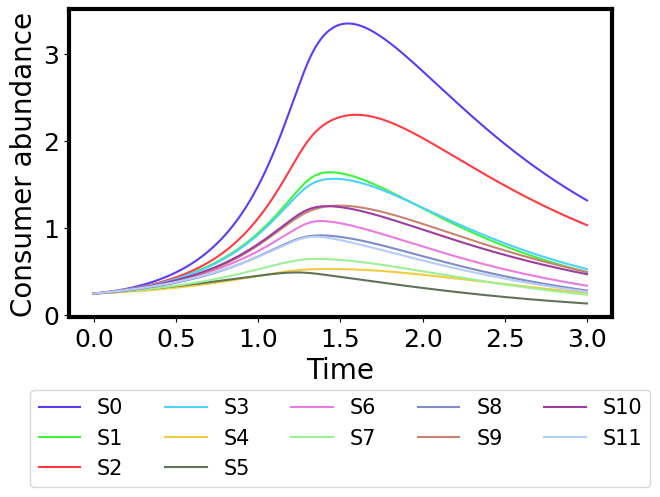

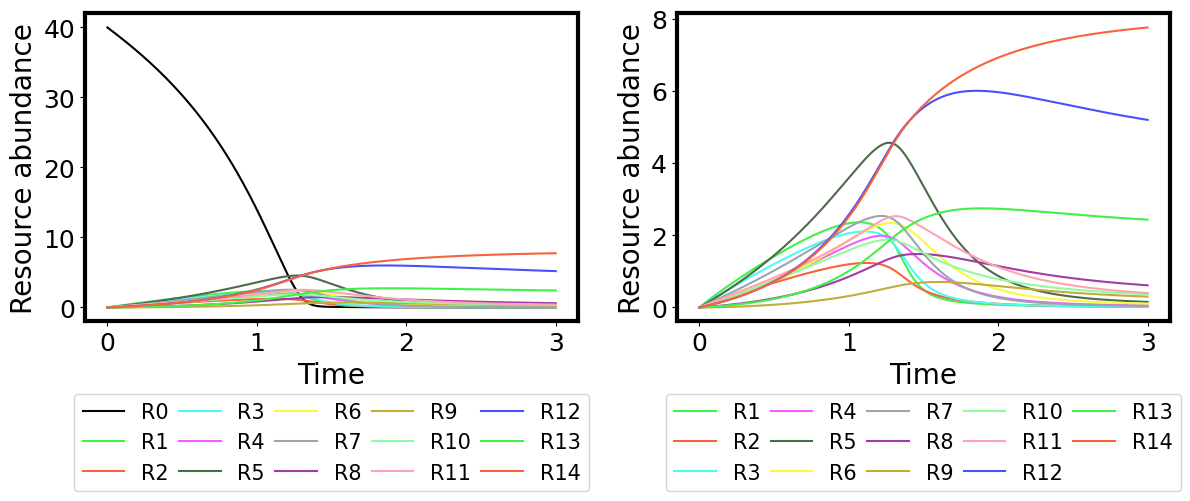

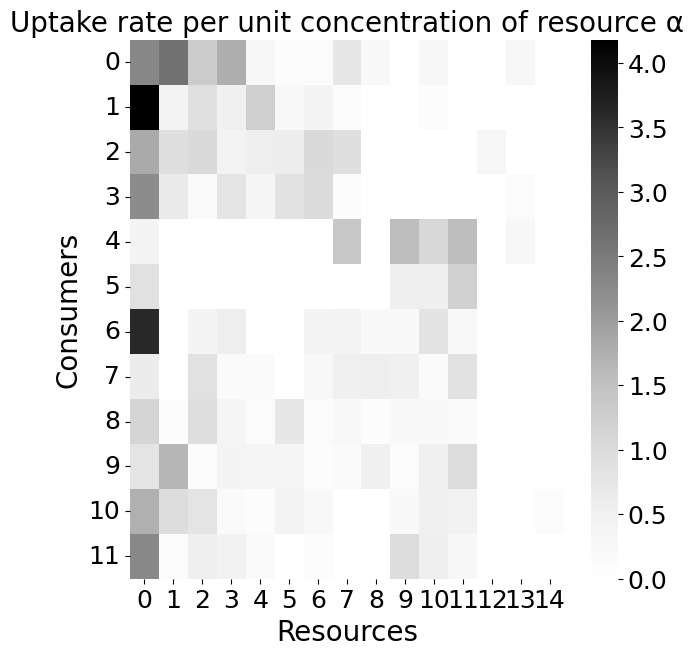

,Time,S0,S1,S2,S3,S4,S5,S6,S7,S8,...,R5,R6,R7,R8,R9,R10,R11,R12,R13,R14
0,0.0000,0.250000,0.250000,0.250000,0.250000,0.250000,0.250000,0.250000,0.250000,0.250000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.0006,0.250104,0.250111,0.250100,0.250103,0.250047,0.250081,0.250109,0.250067,0.250088,...,0.001426,0.000594,0.001101,0.000179,0.000019,0.000838,0.000994,0.000523,0.000130,0.000549
2,0.0012,0.250208,0.250222,0.250200,0.250207,0.250094,0.250161,0.250219,0.250135,0.250176,...,0.002853,0.001188,0.002202,0.000359,0.000038,0.001675,0.001987,0.001047,0.000261,0.001099
3,0.0018,0.250312,0.250333,0.250300,0.250310,0.250142,0.250242,0.250328,0.250203,0.250264,...,0.004280,0.001783,0.003303,0.000539,0.000057,0.002513,0.002980,0.001572,0.000391,0.001649
4,0.0024,0.250417,0.250444,0.250400,0.250414,0.250189,0.250322,0.250438,0.250270,0.250353,...,0.005708,0.002379,0.004404,0.000719,0.000076,0.003351,0.003974,0.002097,0.000522,0.002199
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,2.9976,1.320779,0.497895,1.036593,0.531668,0.257998,0.136762,0.341035,0.237176,0.286077,...,0.154333,0.107212,0.042436,0.614474,0.300335,0.365790,0.400130,5.197949,2.432916,7.754272
4996,2.9982,1.320129,0.497611,1.036126,0.531380,0.257889,0.136689,0.340852,0.237057,0.285919,...,0.154242,0.107157,0.042411,0.614303,0.300240,0.365678,0.399969,5.197549,2.432770,7.754505
4997,2.9988,1.319480,0.497326,1.035659,0.531091,0.257781,0.136616,0.340668,0.236938,0.285760,...,0.154151,0.107102,0.042386,0.614131,0.300145,0.365566,0.399808,5.197150,2.432624,7.754737
4998,2.9994,1.318830,0.497041,1.035193,0.530803,0.257673,0.136543,0.340485,0.236819,0.285602,...,0.154060,0.107048,0.042361,0.613960,0.300050,0.365453,0.399647,5.196751,2.432478,7.754969


In [7]:
from IPython.display import Image
from community_simulator import *
from community_simulator.usertools import *
from community_simulator.visualization import *
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.backends import backend_pdf as bpdf
import distinctipy

import pickle as pkl
import sys
import os

# Get the current working directory (where the script is run from)
current_dir = os.getcwd()

# Get the parent directory
parent_dir = os.path.dirname(os.path.dirname(current_dir))

# Add the parent directory to sys.path
sys.path.append(parent_dir)

params = {'legend.fontsize': 15,
          'figure.figsize': (7, 7),
          'axes.labelsize': 20,
          'axes.titlesize': 20,
          'axes.linewidth': 3,
          'xtick.labelsize':18,
          'ytick.labelsize':18,
          'xtick.labelsize':18,
          'ytick.labelsize':18,
          'svg.fonttype':'none'}
plt.rcParams.update(params)

species = 12
resources = 15
experiments = 4000

# np.random.seed(2)
assumptions = a_default.copy()
assumptions.update({'SA':np.array([4,2]),
                    'MA':np.array([8,4,3]),
                    'Sgen':6,
                    'muc':8,
                    'sigc': 2,
                    'R0_food':40,
                    'n_wells':experiments,
                    'food':0,
                    'S':species,
                    'q':0.85,
                    'l':0.7,
                    'sampling': 'Gamma',
                    'fs':0.75,
                    'fw':0.15,
                    'sparcity':0.7,
                    'response': 'type II',
                    'sigma_max':6,
                    # 'regulation': 'mass',
                    # 'regulation': 'energy',
                    # 'nreg':2,
                    'w':np.array([1] + 4*[0.7] + 3*[0.5] + 2*[0.7] + 2*[0.4] + 3*[0.5]),
                    'metabolism':'specific',
                    'rs':0.7,
                    })

init_state = MakeInitialState(assumptions)
params = MakeParams(assumptions)
def dNdt(N,R,params):
    return MakeConsumerDynamics(assumptions)(N,R,params)
def dRdt(N,R,params):
    return MakeResourceDynamics(assumptions)(N,R,params)
dynamics = [dNdt,dRdt]

np.random.seed(1234)
MyPlate = Community(init_state,dynamics,params,parallel=True)
all_species = np.ones((species,1))
single_species = np.zeros((species,species))
leave_one_out = np.ones((species,species))
for i in range(MyPlate.N.shape[0]):
    single_species[i,i] = 1
    leave_one_out[i,i] = 0
if species * 2 >= experiments:
    random = np.random.randint(2, size=(species, experiments - 1))
    experiment_matrix = np.concatenate((all_species, random),axis=1) * (3/species)
else:
    random = np.random.randint(2, size=(species, int(experiments - ((species * 2)+1))))
    experiment_matrix = np.concatenate((all_species, single_species, leave_one_out, random),axis=1) * (3/species)
MyPlate.N = MyPlate.N * experiment_matrix

c_iα = pd.read_csv(f'{parent_dir}/community-simulator/consumer_preference_{species}s{resources}r_simple.csv', index_col=0)
MyPlate.params['c'] = c_iα.values
c_iα.to_csv(f'consumer_preference_{species}s{resources}r_simple.csv')
D_αβ_10 = pd.read_csv(f'{parent_dir}/community-simulator/resource_conversion_{species}s{resources}r_simple.csv', index_col=0).values
MyPlate.params['D'][10] = D_αβ_10
for i in range(len(MyPlate.params['D'])):
    MyPlate.params['D'][i][MyPlate.params['D'][i] < 1e-3] = 0
    for j in range(MyPlate.params['D'][i].shape[1]):
        for k in range(MyPlate.params['D'][i].shape[0]):
            if j == k:
                MyPlate.params['D'][i][k,j] = 0
    MyPlate.params['D'][i] = MyPlate.params['D'][i] / MyPlate.params['D'][i].sum(axis=0)
D_αβ = np.array(MyPlate.params['D'].copy())
np.save(f'metabolic_matrix_{species}s{resources}r_simple.npy', D_αβ)

# D_αβ = np.load(f'{parent_dir}/community-simulator/metabolic_matrix_30s15r.npy')
# MyPlate.params['D'] = [D_αβ[i] for i in range(species)]

# fig,ax = plt.subplots()
# sns.heatmap(MyPlate.N, ax=ax, cmap='Greys')
# ax.set_title('Initial Consumer Populations')
# plt.savefig('initial_consumer_populations_30s.svg', dpi=300)
# plt.show()

# fig,ax = plt.subplots()
# sns.heatmap(MyPlate.R, ax=ax)
# ax.set_title('Initial Resource Abundances')
# plt.show()

# save MyPlate as a pickle file
with open(f'MyPlate_{species}s{resources}r_simple.pkl', 'wb') as f:
    pkl.dump(MyPlate, f)

t, Ntraj, Rtraj = MyPlate.TestWell(T=3, ns=5000, well_name='W0', show_plots=False)

t = pd.DataFrame(t, columns=['Time'])
Ntraj = pd.DataFrame(Ntraj, columns=MyPlate.N.index.get_level_values(1))
Rtraj = pd.DataFrame(Rtraj, columns=MyPlate.R.index.get_level_values(1))
data = pd.concat([t,Ntraj,Rtraj],axis=1)

colors = distinctipy.get_colors(species, pastel_factor=0.3)
plt.figure(figsize=(7,4))
for i, col in enumerate(Ntraj.columns):
    plt.plot(t, Ntraj[col], color=colors[i % len(colors)], label=col)
plt.xlabel('Time')
plt.ylabel('Consumer abundance')
plt.legend(Ntraj.columns, bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=5)
plt.savefig(f'plots/consumer_abundance_{species}s{resources}r_simple.svg', dpi=300, bbox_inches='tight')
plt.show()

colors = distinctipy.get_colors(species, pastel_factor=0.3)
plt.figure(figsize=(14,4))
plt.subplot(1,2,1)
for i, col in enumerate(Rtraj.columns):
    color = 'black' if col == 'R0' else colors[i % len(colors)]
    plt.plot(t, Rtraj[col], color=color, label=col)
plt.xlabel('Time')
plt.ylabel('Resource abundance')
plt.legend(Rtraj.columns, bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=5, columnspacing=0.5)
plt.subplot(1,2,2)
for i, col in enumerate(Rtraj.columns):
    if col != 'R0':
        plt.plot(t, Rtraj[col], color=colors[i % len(colors)], label=col)
plt.xlabel('Time')
plt.ylabel('Resource abundance')
plt.legend(Rtraj.columns[Rtraj.columns != 'R0'], bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=5, columnspacing=0.5)
plt.savefig(f'plots/resource_abundance_{species}s{resources}r_simple.svg', dpi=300, bbox_inches='tight')
plt.show()

#Plot c matrix
fig,ax=plt.subplots()
sns.heatmap(MyPlate.params['c'],
            cmap='Greys',
            # square=True,
            # xticklabels=False,
            # yticklabels=False,
            ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_title('Uptake rate per unit concentration of resource α')
ax.set_xlabel('Resources')
ax.set_ylabel('Consumers')
plt.savefig(f'plots/consumer_preference_{species}s{resources}r_simple.svg', dpi=300, bbox_inches='tight')
plt.show()

#Plot D matrix
for d in range(len(MyPlate.params['D'])):
    fig,ax=plt.subplots()
    sns.heatmap(MyPlate.params['D'][d],
                cmap='Greys',
                square=True,
                # xticklabels=False,
                # yticklabels=False,
                ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    ax.set_title(f'Species {d}\nFraction of byproducts from\nresource β converted to α')
    ax.set_xlabel('In')
    ax.set_ylabel('Out')
    plt.savefig(f'plots/metabolic_matrix_{species}s{resources}r_{d}_simple.svg', dpi=300, bbox_inches='tight')
    plt.close()
    # plt.show()

data

## 12 species - Base

/home/acs98/Documents/Venturelli-lab/coalescence/community-simulator/community_simulator/__init__.py:426: FutureWarning: The series.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  t, out = IntegrateWell(self,{'y0':N_well.append(R_well).values,'params':params_well},T=T,ns=ns,T0=T0,


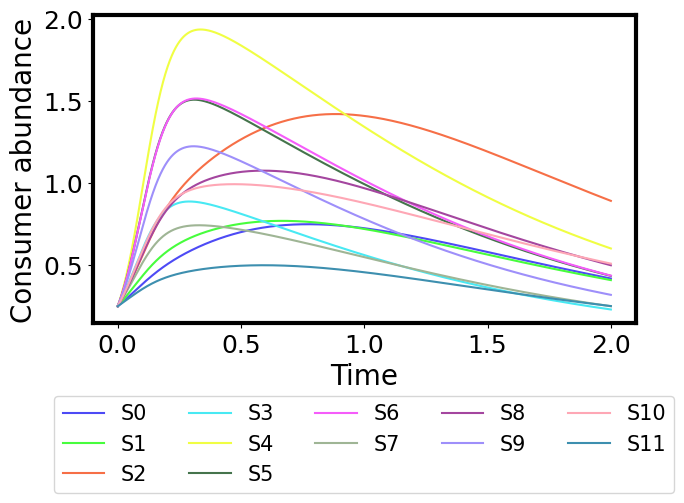

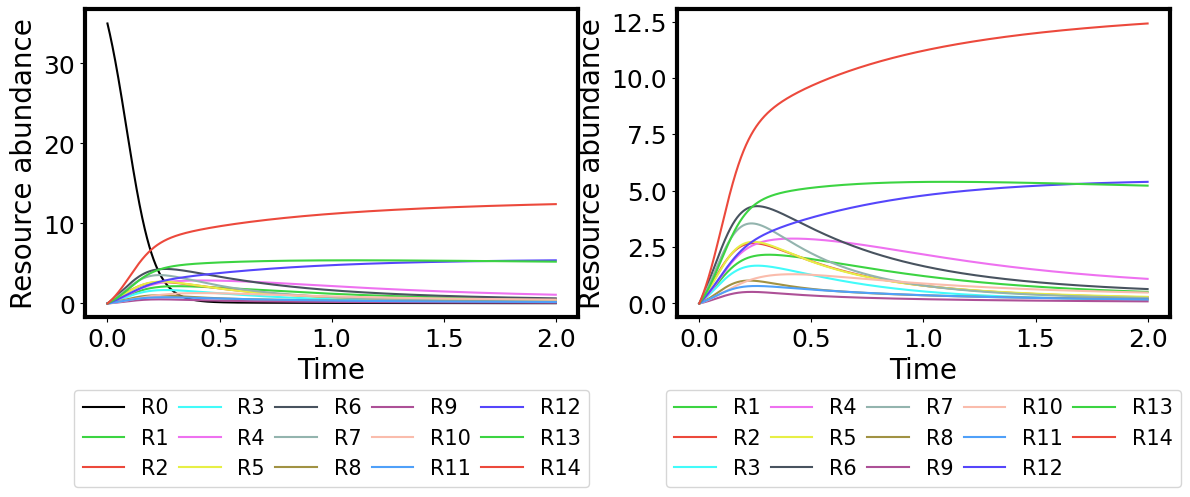

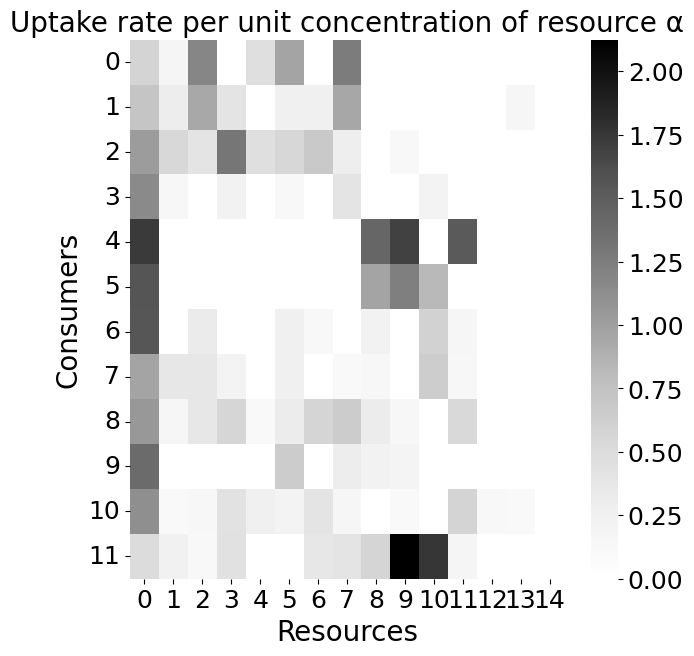

,Time,S0,S1,S2,S3,S4,S5,S6,S7,S8,...,R5,R6,R7,R8,R9,R10,R11,R12,R13,R14
0,0.0000,0.250000,0.250000,0.250000,0.250000,0.250000,0.250000,0.250000,0.250000,0.250000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.0004,0.250503,0.250666,0.250978,0.251112,0.251719,0.251550,0.251542,0.250914,0.251007,...,0.004942,0.008118,0.006574,0.001675,0.000876,0.001371,0.001495,0.003884,0.005261,0.009044
2,0.0008,0.251006,0.251333,0.251958,0.252228,0.253446,0.253108,0.253091,0.251830,0.252016,...,0.009900,0.016260,0.013169,0.003357,0.001756,0.002746,0.002994,0.007781,0.010545,0.018129
3,0.0012,0.251510,0.252002,0.252942,0.253347,0.255184,0.254673,0.254648,0.252748,0.253028,...,0.014874,0.024423,0.019786,0.005047,0.002639,0.004124,0.004497,0.011690,0.015853,0.027255
4,0.0016,0.252014,0.252671,0.253928,0.254469,0.256931,0.256245,0.256212,0.253668,0.254044,...,0.019863,0.032610,0.026424,0.006744,0.003526,0.005507,0.006005,0.015611,0.021183,0.036422
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,1.9984,0.419623,0.409990,0.893178,0.230916,0.603023,0.435893,0.437353,0.250723,0.500593,...,0.294578,0.640034,0.246217,0.194697,0.094063,0.484489,0.184120,5.394967,5.227360,12.418764
4996,1.9988,0.419503,0.409877,0.892946,0.230830,0.602817,0.435741,0.437197,0.250637,0.500435,...,0.294503,0.639866,0.246144,0.194664,0.094045,0.484407,0.184084,5.395052,5.227262,12.419024
4997,1.9992,0.419384,0.409765,0.892714,0.230745,0.602610,0.435589,0.437041,0.250551,0.500278,...,0.294429,0.639699,0.246072,0.194630,0.094027,0.484324,0.184048,5.395138,5.227164,12.419283
4998,1.9996,0.419265,0.409653,0.892481,0.230659,0.602404,0.435437,0.436884,0.250465,0.500121,...,0.294355,0.639531,0.245999,0.194597,0.094009,0.484242,0.184012,5.395223,5.227067,12.419543


In [8]:
from IPython.display import Image
from community_simulator import *
from community_simulator.usertools import *
from community_simulator.visualization import *
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.backends import backend_pdf as bpdf
import distinctipy

import pickle as pkl
import sys
import os

# Get the current working directory (where the script is run from)
current_dir = os.getcwd()

# Get the parent directory
parent_dir = os.path.dirname(os.path.dirname(current_dir))

# Add the parent directory to sys.path
sys.path.append(parent_dir)

params = {'legend.fontsize': 15,
          'figure.figsize': (7, 7),
          'axes.labelsize': 20,
          'axes.titlesize': 20,
          'axes.linewidth': 3,
          'xtick.labelsize':18,
          'ytick.labelsize':18,
          'xtick.labelsize':18,
          'ytick.labelsize':18,
          'svg.fonttype':'none'}
plt.rcParams.update(params)

species = 12
resources = 15
experiments = 4000

# np.random.seed(2)
assumptions = a_default.copy()
assumptions.update({'SA':np.array([4,2]),
                    'MA':np.array([8,4,3]),
                    'Sgen':6,
                    'muc':5,
                    'sigc': 1.5,
                    'R0_food':35,
                    'n_wells':experiments,
                    'food':0,
                    'S':species,
                    'q':0.85,
                    'l':0.7,
                    'sampling': 'Gamma',
                    'fs':0.7,
                    'fw':0.2,
                    'sparcity':0.7,
                    # 'response': 'type II',
                    # 'sigma_max':6,
                    # 'regulation': 'mass',
                    # 'regulation': 'energy',
                    # 'nreg':2,
                    'w':np.array([1] + 4*[0.7] + 3*[0.5] + 2*[0.7] + 2*[0.4] + 3*[0.5]),
                    'metabolism':'specific',
                    'rs':0.7,
                    })

init_state = MakeInitialState(assumptions)
params = MakeParams(assumptions)
def dNdt(N,R,params):
    return MakeConsumerDynamics(assumptions)(N,R,params)
def dRdt(N,R,params):
    return MakeResourceDynamics(assumptions)(N,R,params)
dynamics = [dNdt,dRdt]

np.random.seed(1234)
MyPlate = Community(init_state,dynamics,params,parallel=True)
all_species = np.ones((species,1))
single_species = np.zeros((species,species))
leave_one_out = np.ones((species,species))
for i in range(MyPlate.N.shape[0]):
    single_species[i,i] = 1
    leave_one_out[i,i] = 0
if species * 2 >= experiments:
    random = np.random.randint(2, size=(species, experiments - 1))
    experiment_matrix = np.concatenate((all_species, random),axis=1) * (3/species)
else:
    random = np.random.randint(2, size=(species, int(experiments - ((species * 2)+1))))
    experiment_matrix = np.concatenate((all_species, single_species, leave_one_out, random),axis=1) * (3/species)
MyPlate.N = MyPlate.N * experiment_matrix

c_iα = pd.read_csv(f'{parent_dir}/community-simulator/consumer_preference_{species}s{resources}r_base.csv', index_col=0)
MyPlate.params['c'] = c_iα.values
c_iα.to_csv(f'consumer_preference_{species}s{resources}r_base.csv')
D_αβ_8 = pd.read_csv(f'{parent_dir}/community-simulator/resource_conversion_{species}s{resources}r_simple.csv', index_col=0).values
MyPlate.params['D'][8] = D_αβ_8
for i in range(len(MyPlate.params['D'])):
    MyPlate.params['D'][i][MyPlate.params['D'][i] < 1e-3] = 0
    for j in range(MyPlate.params['D'][i].shape[1]):
        for k in range(MyPlate.params['D'][i].shape[0]):
            if j == k:
                MyPlate.params['D'][i][k,j] = 0
    MyPlate.params['D'][i] = MyPlate.params['D'][i] / MyPlate.params['D'][i].sum(axis=0)
D_αβ = np.array(MyPlate.params['D'].copy())
np.save(f'metabolic_matrix_{species}s{resources}r_base.npy', D_αβ)

# D_αβ = np.load(f'{parent_dir}/community-simulator/metabolic_matrix_30s15r.npy')
# MyPlate.params['D'] = [D_αβ[i] for i in range(species)]

# fig,ax = plt.subplots()
# sns.heatmap(MyPlate.N, ax=ax, cmap='Greys')
# ax.set_title('Initial Consumer Populations')
# plt.savefig('initial_consumer_populations_30s.svg', dpi=300)
# plt.show()

# fig,ax = plt.subplots()
# sns.heatmap(MyPlate.R, ax=ax)
# ax.set_title('Initial Resource Abundances')
# plt.show()

# save MyPlate as a pickle file
with open(f'MyPlate_{species}s{resources}r_base.pkl', 'wb') as f:
    pkl.dump(MyPlate, f)

t, Ntraj, Rtraj = MyPlate.TestWell(T=2, ns=5000, well_name='W0', show_plots=False)

t = pd.DataFrame(t, columns=['Time'])
Ntraj = pd.DataFrame(Ntraj, columns=MyPlate.N.index.get_level_values(1))
Rtraj = pd.DataFrame(Rtraj, columns=MyPlate.R.index.get_level_values(1))
data = pd.concat([t,Ntraj,Rtraj],axis=1)

colors = distinctipy.get_colors(species, pastel_factor=0.3)
plt.figure(figsize=(7,4))
for i, col in enumerate(Ntraj.columns):
    plt.plot(t, Ntraj[col], color=colors[i % len(colors)], label=col)
plt.xlabel('Time')
plt.ylabel('Consumer abundance')
plt.legend(Ntraj.columns, bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=5)
plt.savefig(f'plots/consumer_abundance_{species}s{resources}r_base.png', dpi=300, bbox_inches='tight')
plt.show()

colors = distinctipy.get_colors(species, pastel_factor=0.3)
plt.figure(figsize=(14,4))
plt.subplot(1,2,1)
for i, col in enumerate(Rtraj.columns):
    color = 'black' if col == 'R0' else colors[i % len(colors)]
    plt.plot(t, Rtraj[col], color=color, label=col)
plt.xlabel('Time')
plt.ylabel('Resource abundance')
plt.legend(Rtraj.columns, bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=5, columnspacing=0.5)
plt.subplot(1,2,2)
for i, col in enumerate(Rtraj.columns):
    if col != 'R0':
        plt.plot(t, Rtraj[col], color=colors[i % len(colors)], label=col)
plt.xlabel('Time')
plt.ylabel('Resource abundance')
plt.legend(Rtraj.columns[Rtraj.columns != 'R0'], bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=5, columnspacing=0.5)
plt.savefig(f'plots/resource_abundance_{species}s{resources}r_base.png', dpi=300, bbox_inches='tight')
plt.show()

#Plot c matrix
fig,ax=plt.subplots()
sns.heatmap(MyPlate.params['c'],
            cmap='Greys',
            # square=True,
            # xticklabels=False,
            # yticklabels=False,
            ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_title('Uptake rate per unit concentration of resource α')
ax.set_xlabel('Resources')
ax.set_ylabel('Consumers')
plt.savefig(f'plots/consumer_preference_{species}s{resources}r_base.svg', dpi=300, bbox_inches='tight')
plt.show()

#Plot D matrix
for d in range(len(MyPlate.params['D'])):
    fig,ax=plt.subplots()
    sns.heatmap(MyPlate.params['D'][d],
                cmap='Greys',
                square=True,
                # xticklabels=False,
                # yticklabels=False,
                ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    ax.set_title(f'Species {d}\nFraction of byproducts from\nresource β converted to α')
    ax.set_xlabel('In')
    ax.set_ylabel('Out')
    plt.savefig(f'plots/metabolic_matrix_{species}s{resources}r_{d}_base.svg', dpi=300, bbox_inches='tight')
    plt.close()
    # plt.show()

data

---

## 50 species - Intricate

/home/acs98/Documents/Venturelli-lab/coalescence/community-simulator/community_simulator/__init__.py:426: FutureWarning: The series.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  t, out = IntegrateWell(self,{'y0':N_well.append(R_well).values,'params':params_well},T=T,ns=ns,T0=T0,


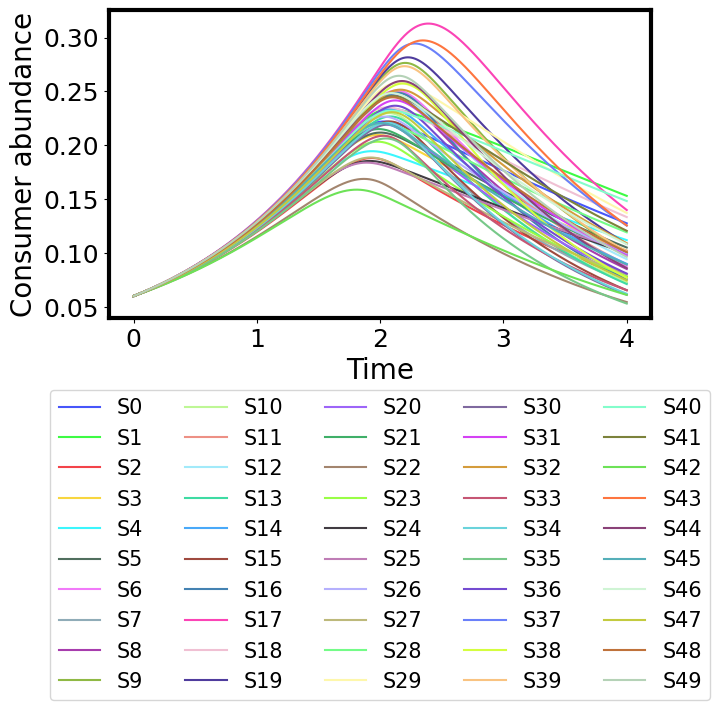

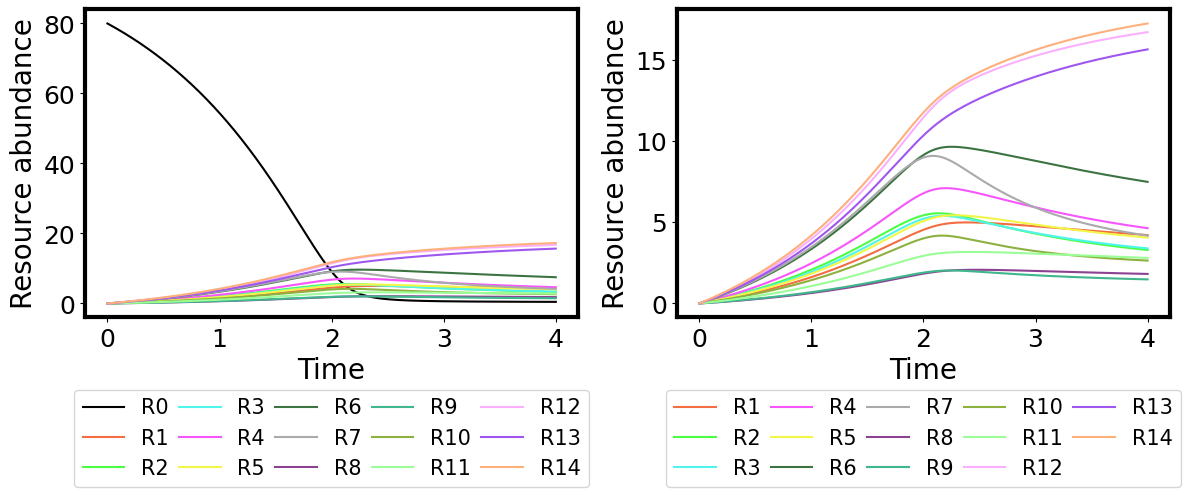

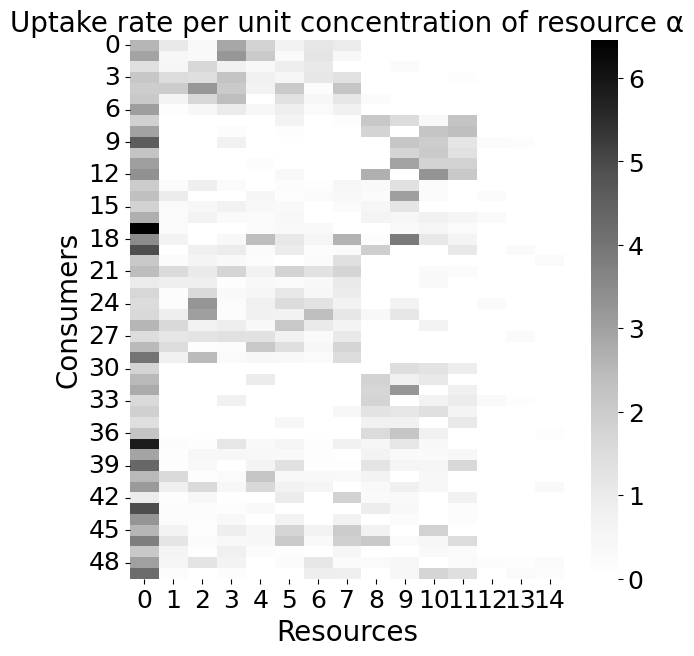

,Time,S0,S1,S2,S3,S4,S5,S6,S7,S8,...,R5,R6,R7,R8,R9,R10,R11,R12,R13,R14
0,0.000000,0.060000,0.060000,0.060000,0.060000,0.060000,0.060000,0.060000,0.060000,0.060000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000800,0.060036,0.060036,0.060034,0.060035,0.060035,0.060035,0.060036,0.060035,0.060036,...,0.001001,0.001832,0.001905,0.000349,0.000384,0.000779,0.000586,0.002162,0.002019,0.002292
2,0.001600,0.060072,0.060073,0.060068,0.060071,0.060070,0.060071,0.060073,0.060070,0.060073,...,0.002002,0.003665,0.003812,0.000699,0.000767,0.001559,0.001172,0.004325,0.004039,0.004586
3,0.002400,0.060108,0.060109,0.060102,0.060107,0.060106,0.060106,0.060109,0.060105,0.060109,...,0.003004,0.005500,0.005719,0.001048,0.001152,0.002339,0.001758,0.006490,0.006060,0.006881
4,0.003201,0.060144,0.060145,0.060136,0.060142,0.060141,0.060142,0.060146,0.060141,0.060145,...,0.004007,0.007335,0.007628,0.001398,0.001536,0.003119,0.002345,0.008655,0.008082,0.009177
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,3.996799,0.127685,0.153150,0.078077,0.102454,0.112040,0.105230,0.088002,0.072378,0.085326,...,4.065973,7.509700,4.186730,1.824139,1.488319,2.649836,2.813518,16.742329,15.677348,17.276847
4996,3.997600,0.127649,0.153115,0.078046,0.102419,0.112009,0.105193,0.087956,0.072342,0.085284,...,4.065479,7.508828,4.185894,1.824016,1.488183,2.649560,2.813347,16.743153,15.678323,17.277760
4997,3.998400,0.127612,0.153079,0.078014,0.102384,0.111979,0.105156,0.087909,0.072306,0.085241,...,4.064985,7.507957,4.185058,1.823894,1.488048,2.649284,2.813176,16.743976,15.679297,17.278673
4998,3.999200,0.127576,0.153043,0.077983,0.102349,0.111949,0.105120,0.087863,0.072270,0.085198,...,4.064491,7.507086,4.184223,1.823771,1.487912,2.649008,2.813005,16.744799,15.680271,17.279585


In [9]:
from IPython.display import Image
from community_simulator import *
from community_simulator.usertools import *
from community_simulator.visualization import *
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.backends import backend_pdf as bpdf
import distinctipy

import pickle as pkl
import sys
import os

# Get the current working directory (where the script is run from)
current_dir = os.getcwd()

# Get the parent directory
parent_dir = os.path.dirname(os.path.dirname(current_dir))

# Add the parent directory to sys.path
sys.path.append(parent_dir)

params = {'legend.fontsize': 15,
          'figure.figsize': (7, 7),
          'axes.labelsize': 20,
          'axes.titlesize': 20,
          'axes.linewidth': 3,
          'xtick.labelsize':18,
          'ytick.labelsize':18,
          'xtick.labelsize':18,
          'ytick.labelsize':18,
          'svg.fonttype':'none'}
plt.rcParams.update(params)

species = 50
resources = 15
experiments = 4000

assumptions = a_default.copy()
assumptions.update({'SA':np.array([17,13]),
                    'MA':np.array([8,4,3]),
                    'Sgen':20,
                    'muc':10,
                    'R0_food':80,
                    'n_wells':experiments,
                    'food':0,
                    'S':species,
                    'q':0.85,
                    'l':0.7,
                    'sampling': 'Gamma',
                    'fs':0.55,
                    'fw':0.35,
                    'sparcity':0.7,
                    'response': 'type II',
                    'sigma_max':6,
                    'regulation': 'mass',
                    # 'regulation': 'energy',
                    'nreg':2,
                    'w':np.array([1] + 4*[0.7] + 3*[0.5] + 2*[0.7] + 2*[0.4] + 3*[0.5]),
                    'metabolism':'specific',
                    'rs':0.7,
                    })

init_state = MakeInitialState(assumptions)
params = MakeParams(assumptions)
def dNdt(N,R,params):
    return MakeConsumerDynamics(assumptions)(N,R,params)
def dRdt(N,R,params):
    return MakeResourceDynamics(assumptions)(N,R,params)
dynamics = [dNdt,dRdt]

np.random.seed(0)
MyPlate = Community(init_state,dynamics,params,parallel=True)
all_species = np.ones((species,1))
single_species = np.zeros((species,species))
leave_one_out = np.ones((species,species))
for i in range(MyPlate.N.shape[0]):
    single_species[i,i] = 1
    leave_one_out[i,i] = 0
if species * 2 >= experiments:
    random = np.random.randint(2, size=(species, experiments - 1))
    experiment_matrix = np.concatenate((all_species, random),axis=1) * (3/species)
else:
    random = np.random.randint(2, size=(species, int(experiments - ((species * 2)+1))))
    experiment_matrix = np.concatenate((all_species, single_species, leave_one_out, random),axis=1) * (3/species)
MyPlate.N = MyPlate.N * experiment_matrix

c_iα = pd.read_csv(f'{parent_dir}/community-simulator/consumer_preference_{species}s{resources}r_intricate.csv', index_col=0)
MyPlate.params['c'] = c_iα.values
c_iα.to_csv(f'consumer_preference_{species}s{resources}r_intricate.csv')
D_αβ_17 = pd.read_csv(f'{parent_dir}/community-simulator/resource_conversion_{species}s{resources}r_intricate.csv', index_col=0).values
MyPlate.params['D'][17] = D_αβ_17
for i in range(len(MyPlate.params['D'])):
    MyPlate.params['D'][i][MyPlate.params['D'][i] < 1e-3] = 0
    for j in range(MyPlate.params['D'][i].shape[1]):
        for k in range(MyPlate.params['D'][i].shape[0]):
            if j == k:
                MyPlate.params['D'][i][k,j] = 0
    MyPlate.params['D'][i] = MyPlate.params['D'][i] / MyPlate.params['D'][i].sum(axis=0)
D_αβ = np.array(MyPlate.params['D'].copy())
np.save(f'metabolic_matrix_{species}s{resources}r_intricate.npy', D_αβ)

# D_αβ = np.load(f'{parent_dir}/community-simulator/metabolic_matrix_30s15r.npy')
# MyPlate.params['D'] = [D_αβ[i] for i in range(species)]

# fig,ax = plt.subplots()
# sns.heatmap(MyPlate.N, ax=ax, cmap='Greys')
# ax.set_title('Initial Consumer Populations')
# plt.savefig('initial_consumer_populations_30s.svg', dpi=300)
# plt.show()

# fig,ax = plt.subplots()
# sns.heatmap(MyPlate.R, ax=ax)
# ax.set_title('Initial Resource Abundances')
# plt.show()

# save MyPlate as a pickle file
with open(f'MyPlate_{species}s{resources}r_intricate.pkl', 'wb') as f:
    pkl.dump(MyPlate, f)

t, Ntraj, Rtraj = MyPlate.TestWell(T=4, ns=5000, well_name='W0', show_plots=False)

t = pd.DataFrame(t, columns=['Time'])
Ntraj = pd.DataFrame(Ntraj, columns=MyPlate.N.index.get_level_values(1))
Rtraj = pd.DataFrame(Rtraj, columns=MyPlate.R.index.get_level_values(1))
data = pd.concat([t,Ntraj,Rtraj],axis=1)

colors = distinctipy.get_colors(species, pastel_factor=0.3)
plt.figure(figsize=(7,4))
for i, col in enumerate(Ntraj.columns):
    plt.plot(t, Ntraj[col], color=colors[i % len(colors)], label=col)
plt.xlabel('Time')
plt.ylabel('Consumer abundance')
plt.legend(Ntraj.columns, bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=5)
plt.savefig(f'plots/consumer_abundance_{species}s{resources}r_intricate.svg', dpi=300, bbox_inches='tight')
plt.show()

colors = distinctipy.get_colors(species, pastel_factor=0.3)
plt.figure(figsize=(14,4))
plt.subplot(1,2,1)
for i, col in enumerate(Rtraj.columns):
    color = 'black' if col == 'R0' else colors[i % len(colors)]
    plt.plot(t, Rtraj[col], color=color, label=col)
plt.xlabel('Time')
plt.ylabel('Resource abundance')
plt.legend(Rtraj.columns, bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=5, columnspacing=0.5)
plt.subplot(1,2,2)
for i, col in enumerate(Rtraj.columns):
    if col != 'R0':
        plt.plot(t, Rtraj[col], color=colors[i % len(colors)], label=col)
plt.xlabel('Time')
plt.ylabel('Resource abundance')
plt.legend(Rtraj.columns[Rtraj.columns != 'R0'], bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=5, columnspacing=0.5)
plt.savefig(f'plots/resource_abundance_{species}s{resources}r_intricate.svg', dpi=300, bbox_inches='tight')
plt.show()

#Plot c matrix
fig,ax=plt.subplots()
sns.heatmap(MyPlate.params['c'],
            cmap='Greys',
            # square=True,
            # xticklabels=False,
            # yticklabels=False,
            ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_title('Uptake rate per unit concentration of resource α')
ax.set_xlabel('Resources')
ax.set_ylabel('Consumers')
plt.savefig(f'plots/consumer_preference_{species}s{resources}r_intricate.svg', dpi=300, bbox_inches='tight')
plt.show()

#Plot D matrix
for d in range(len(MyPlate.params['D'])):
    fig,ax=plt.subplots()
    sns.heatmap(MyPlate.params['D'][d],
                cmap='Greys',
                square=True,
                # xticklabels=False,
                # yticklabels=False,
                ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    ax.set_title(f'Species {d}\nFraction of byproducts from\nresource β converted to α')
    ax.set_xlabel('In')
    ax.set_ylabel('Out')
    plt.savefig(f'plots/metabolic_matrix_{species}s{resources}r_{d}_intricate.svg', dpi=300, bbox_inches='tight')
    plt.close()
    # plt.show()

data

## 50 species - simple

/home/acs98/Documents/Venturelli-lab/coalescence/community-simulator/community_simulator/__init__.py:426: FutureWarning: The series.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  t, out = IntegrateWell(self,{'y0':N_well.append(R_well).values,'params':params_well},T=T,ns=ns,T0=T0,


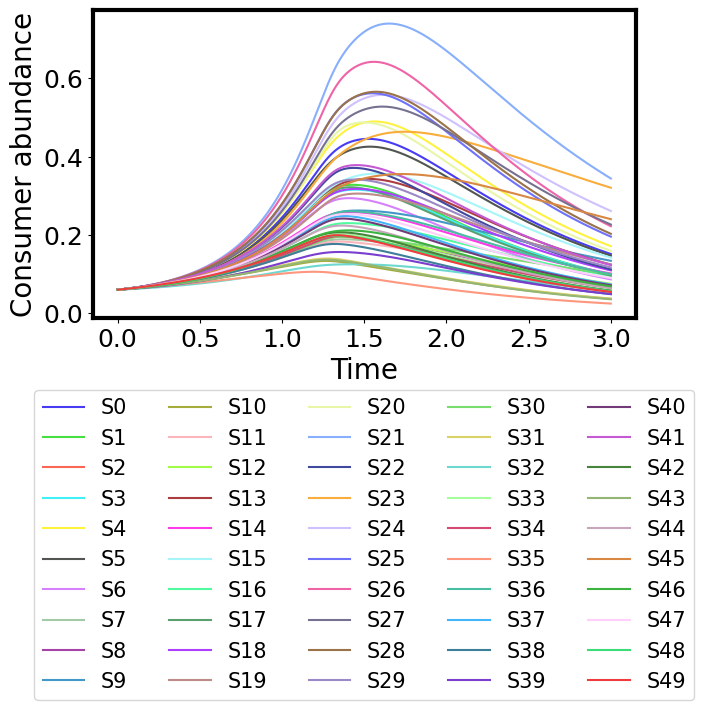

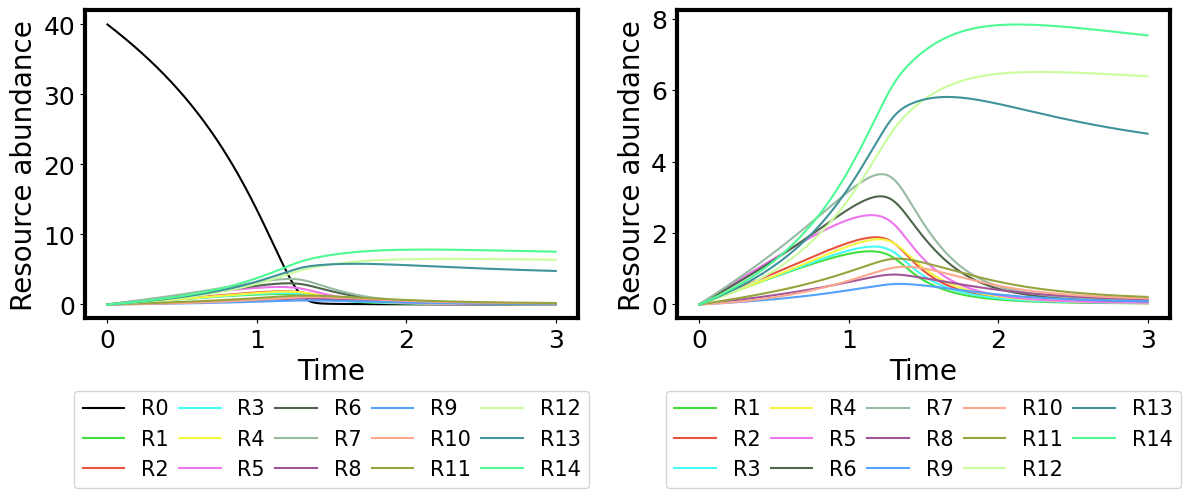

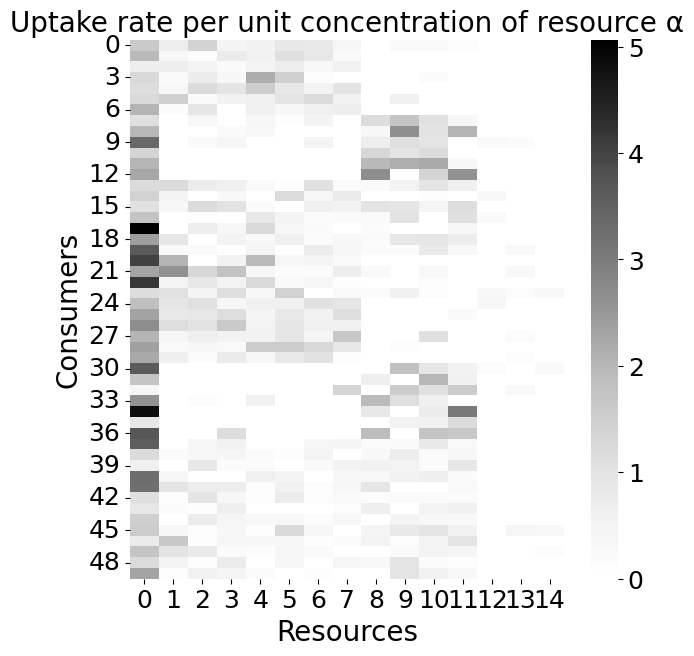

,Time,S0,S1,S2,S3,S4,S5,S6,S7,S8,...,R5,R6,R7,R8,R9,R10,R11,R12,R13,R14
0,0.0000,0.060000,0.060000,0.060000,0.060000,0.060000,0.060000,0.060000,0.060000,0.060000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.0006,0.060023,0.060024,0.060018,0.060022,0.060021,0.060022,0.060024,0.060021,0.060024,...,0.001596,0.001385,0.001639,0.000283,0.000133,0.000111,0.000384,0.000803,0.000957,0.001056
2,0.0012,0.060047,0.060048,0.060035,0.060044,0.060043,0.060044,0.060049,0.060042,0.060049,...,0.003192,0.002771,0.003279,0.000566,0.000267,0.000222,0.000767,0.001606,0.001914,0.002113
3,0.0018,0.060070,0.060073,0.060053,0.060066,0.060064,0.060066,0.060073,0.060063,0.060073,...,0.004788,0.004157,0.004919,0.000849,0.000400,0.000334,0.001151,0.002411,0.002872,0.003170
4,0.0024,0.060094,0.060097,0.060070,0.060088,0.060085,0.060088,0.060098,0.060084,0.060097,...,0.006384,0.005543,0.006559,0.001132,0.000533,0.000446,0.001535,0.003215,0.003831,0.004228
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,2.9976,0.151617,0.099077,0.054531,0.098874,0.171731,0.147417,0.086598,0.066087,0.071382,...,0.050696,0.092270,0.139980,0.146620,0.088158,0.169155,0.212142,6.392996,4.786335,7.538218
4996,2.9982,0.151532,0.099021,0.054499,0.098818,0.171635,0.147335,0.086548,0.066051,0.071345,...,0.050672,0.092233,0.139948,0.146559,0.088117,0.169083,0.212048,6.392857,4.785976,7.537938
4997,2.9988,0.151447,0.098964,0.054468,0.098761,0.171539,0.147253,0.086498,0.066016,0.071308,...,0.050649,0.092195,0.139917,0.146499,0.088076,0.169011,0.211954,6.392718,4.785618,7.537658
4998,2.9994,0.151362,0.098907,0.054436,0.098705,0.171444,0.147171,0.086449,0.065981,0.071271,...,0.050626,0.092158,0.139885,0.146439,0.088035,0.168940,0.211861,6.392579,4.785259,7.537378


In [10]:
from IPython.display import Image
from community_simulator import *
from community_simulator.usertools import *
from community_simulator.visualization import *
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.backends import backend_pdf as bpdf
import distinctipy

import pickle as pkl
import sys
import os

# Get the current working directory (where the script is run from)
current_dir = os.getcwd()

# Get the parent directory
parent_dir = os.path.dirname(os.path.dirname(current_dir))

# Add the parent directory to sys.path
sys.path.append(parent_dir)

params = {'legend.fontsize': 15,
          'figure.figsize': (7, 7),
          'axes.labelsize': 20,
          'axes.titlesize': 20,
          'axes.linewidth': 3,
          'xtick.labelsize':18,
          'ytick.labelsize':18,
          'xtick.labelsize':18,
          'ytick.labelsize':18,
          'svg.fonttype':'none'}
plt.rcParams.update(params)

species = 50
resources = 15
experiments = 4000
assumptions = a_default.copy()
assumptions.update({'SA':np.array([17,13]),
                    'MA':np.array([8,4,3]),
                    'Sgen':20,
                    'muc':8,
                    'sigc': 2,
                    'R0_food':40,
                    'n_wells':experiments,
                    'food':0,
                    'S':species,
                    'q':0.85,
                    'l':0.7,
                    'sampling': 'Gamma',
                    'fs':0.75,
                    'fw':0.15,
                    'sparcity':0.7,
                    'response': 'type II',
                    'sigma_max':6,
                    # 'regulation': 'mass',
                    # 'regulation': 'energy',
                    # 'nreg':2,
                    'w':np.array([1] + 4*[0.7] + 3*[0.5] + 2*[0.7] + 2*[0.4] + 3*[0.5]),
                    'metabolism':'specific',
                    'rs':0.7,
                    })

init_state = MakeInitialState(assumptions)
params = MakeParams(assumptions)
def dNdt(N,R,params):
    return MakeConsumerDynamics(assumptions)(N,R,params)
def dRdt(N,R,params):
    return MakeResourceDynamics(assumptions)(N,R,params)
dynamics = [dNdt,dRdt]

np.random.seed(1234)
MyPlate = Community(init_state,dynamics,params,parallel=True)
all_species = np.ones((species,1))
single_species = np.zeros((species,species))
leave_one_out = np.ones((species,species))
for i in range(MyPlate.N.shape[0]):
    single_species[i,i] = 1
    leave_one_out[i,i] = 0
if species * 2 >= experiments:
    random = np.random.randint(2, size=(species, experiments - 1))
    experiment_matrix = np.concatenate((all_species, random),axis=1) * (3/species)
else:
    random = np.random.randint(2, size=(species, int(experiments - ((species * 2)+1))))
    experiment_matrix = np.concatenate((all_species, single_species, leave_one_out, random),axis=1) * (3/species)
MyPlate.N = MyPlate.N * experiment_matrix

c_iα = pd.read_csv(f'{parent_dir}/community-simulator/consumer_preference_{species}s{resources}r_simple.csv', index_col=0)
MyPlate.params['c'] = c_iα.values
c_iα.to_csv(f'consumer_preference_{species}s{resources}r_simple.csv')
D_αβ_27 = pd.read_csv(f'{parent_dir}/community-simulator/resource_conversion_{species}s{resources}r_simple.csv', index_col=0).values
MyPlate.params['D'][27] = D_αβ_27
for i in range(len(MyPlate.params['D'])):
    MyPlate.params['D'][i][MyPlate.params['D'][i] < 1e-3] = 0
    for j in range(MyPlate.params['D'][i].shape[1]):
        for k in range(MyPlate.params['D'][i].shape[0]):
            if j == k:
                MyPlate.params['D'][i][k,j] = 0
    MyPlate.params['D'][i] = MyPlate.params['D'][i] / MyPlate.params['D'][i].sum(axis=0)
D_αβ = np.array(MyPlate.params['D'].copy())
np.save(f'metabolic_matrix_{species}s{resources}r_simple.npy', D_αβ)

# D_αβ = np.load(f'{parent_dir}/community-simulator/metabolic_matrix_30s15r.npy')
# MyPlate.params['D'] = [D_αβ[i] for i in range(species)]

# fig,ax = plt.subplots()
# sns.heatmap(MyPlate.N, ax=ax, cmap='Greys')
# ax.set_title('Initial Consumer Populations')
# plt.savefig('initial_consumer_populations_30s.svg', dpi=300)
# plt.show()

# fig,ax = plt.subplots()
# sns.heatmap(MyPlate.R, ax=ax)
# ax.set_title('Initial Resource Abundances')
# plt.show()

# save MyPlate as a pickle file
with open(f'MyPlate_{species}s{resources}r_simple.pkl', 'wb') as f:
    pkl.dump(MyPlate, f)
    
t, Ntraj, Rtraj = MyPlate.TestWell(T=3, ns=5000, well_name='W0', show_plots=False)

t = pd.DataFrame(t, columns=['Time'])
Ntraj = pd.DataFrame(Ntraj, columns=MyPlate.N.index.get_level_values(1))
Rtraj = pd.DataFrame(Rtraj, columns=MyPlate.R.index.get_level_values(1))
data = pd.concat([t,Ntraj,Rtraj],axis=1)

colors = distinctipy.get_colors(species, pastel_factor=0.3)
plt.figure(figsize=(7,4))
for i, col in enumerate(Ntraj.columns):
    plt.plot(t, Ntraj[col], color=colors[i % len(colors)], label=col)
plt.xlabel('Time')
plt.ylabel('Consumer abundance')
plt.legend(Ntraj.columns, bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=5)
plt.savefig(f'plots/consumer_abundance_{species}s{resources}r_simple.svg', dpi=300, bbox_inches='tight')
plt.show()

colors = distinctipy.get_colors(species, pastel_factor=0.3)
plt.figure(figsize=(14,4))
plt.subplot(1,2,1)
for i, col in enumerate(Rtraj.columns):
    color = 'black' if col == 'R0' else colors[i % len(colors)]
    plt.plot(t, Rtraj[col], color=color, label=col)
plt.xlabel('Time')
plt.ylabel('Resource abundance')
plt.legend(Rtraj.columns, bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=5, columnspacing=0.5)
plt.subplot(1,2,2)
for i, col in enumerate(Rtraj.columns):
    if col != 'R0':
        plt.plot(t, Rtraj[col], color=colors[i % len(colors)], label=col)
plt.xlabel('Time')
plt.ylabel('Resource abundance')
plt.legend(Rtraj.columns[Rtraj.columns != 'R0'], bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=5, columnspacing=0.5)
plt.savefig(f'plots/resource_abundance_{species}s{resources}r_simple.svg', dpi=300, bbox_inches='tight')
plt.show()

#Plot c matrix
fig,ax=plt.subplots()
sns.heatmap(MyPlate.params['c'],
            cmap='Greys',
            # square=True,
            # xticklabels=False,
            # yticklabels=False,
            ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_title('Uptake rate per unit concentration of resource α')
ax.set_xlabel('Resources')
ax.set_ylabel('Consumers')
plt.savefig(f'plots/consumer_preference_{species}s{resources}r_simple.svg', dpi=300, bbox_inches='tight')
plt.show()

#Plot D matrix
for d in range(len(MyPlate.params['D'])):
    fig,ax=plt.subplots()
    sns.heatmap(MyPlate.params['D'][d],
                cmap='Greys',
                square=True,
                # xticklabels=False,
                # yticklabels=False,
                ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    ax.set_title(f'Species {d}\nFraction of byproducts from\nresource β converted to α')
    ax.set_xlabel('In')
    ax.set_ylabel('Out')
    plt.savefig(f'plots/metabolic_matrix_{species}s{resources}r_{d}_simple.svg', dpi=300, bbox_inches='tight')
    plt.close()
    # plt.show()

data

## 50 species - base

/home/acs98/Documents/Venturelli-lab/coalescence/community-simulator/community_simulator/__init__.py:426: FutureWarning: The series.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  t, out = IntegrateWell(self,{'y0':N_well.append(R_well).values,'params':params_well},T=T,ns=ns,T0=T0,


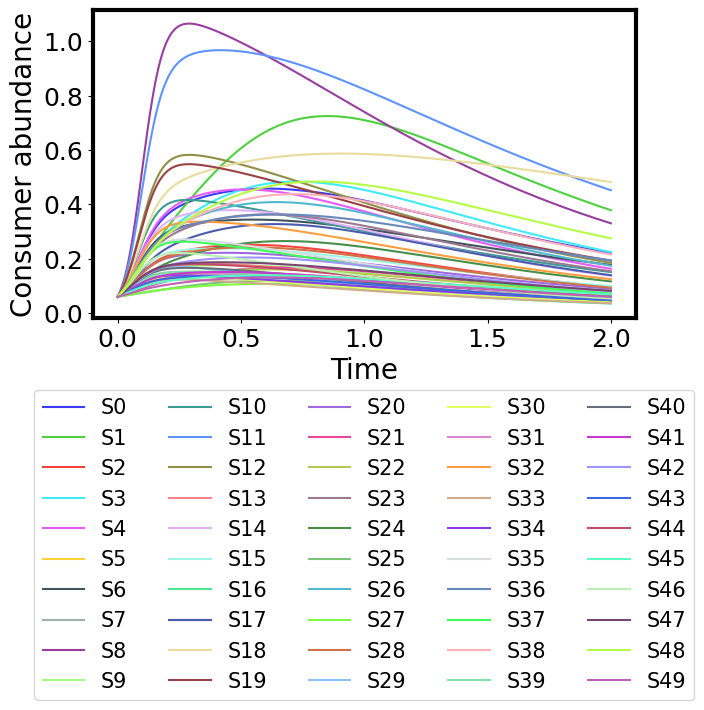

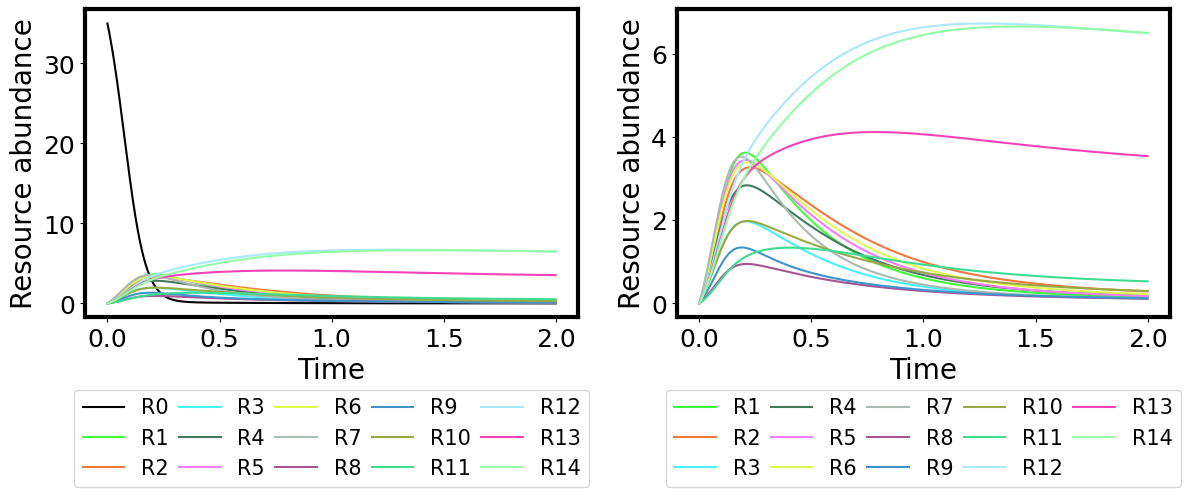

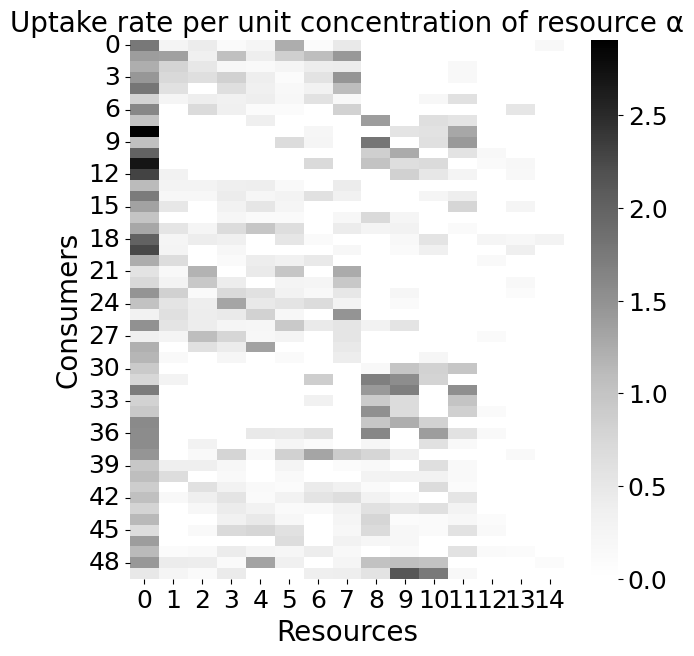

,Time,S0,S1,S2,S3,S4,S5,S6,S7,S8,...,R5,R6,R7,R8,R9,R10,R11,R12,R13,R14
0,0.0000,0.060000,0.060000,0.060000,0.060000,0.060000,0.060000,0.060000,0.060000,0.060000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.0004,0.060421,0.060327,0.060287,0.060342,0.060427,0.060180,0.060382,0.060232,0.060712,...,0.007135,0.006578,0.007849,0.001872,0.002795,0.004218,0.001560,0.004853,0.004427,0.004174
2,0.0008,0.060845,0.060655,0.060576,0.060685,0.060857,0.060360,0.060766,0.060464,0.061432,...,0.014298,0.013183,0.015728,0.003753,0.005603,0.008450,0.003128,0.009728,0.008874,0.008367
3,0.0012,0.061271,0.060984,0.060865,0.061030,0.061289,0.060540,0.061152,0.060697,0.062159,...,0.021490,0.019818,0.023639,0.005641,0.008423,0.012698,0.004703,0.014626,0.013341,0.012579
4,0.0016,0.061700,0.061315,0.061155,0.061377,0.061723,0.060720,0.061540,0.060930,0.062894,...,0.028712,0.026481,0.031581,0.007538,0.011256,0.016960,0.006285,0.019547,0.017827,0.016811
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,1.9984,0.220500,0.379068,0.095499,0.224668,0.163240,0.057233,0.177322,0.045453,0.330847,...,0.177489,0.225343,0.116893,0.115922,0.125973,0.300256,0.531353,6.486587,3.539499,6.499092
4996,1.9988,0.220436,0.378946,0.095465,0.224593,0.163181,0.057213,0.177277,0.045437,0.330732,...,0.177423,0.225269,0.116856,0.115894,0.125943,0.300184,0.531284,6.486407,3.539345,6.498925
4997,1.9992,0.220372,0.378823,0.095431,0.224518,0.163121,0.057193,0.177231,0.045421,0.330618,...,0.177358,0.225196,0.116819,0.115867,0.125913,0.300112,0.531215,6.486227,3.539192,6.498758
4998,1.9996,0.220308,0.378701,0.095397,0.224442,0.163062,0.057173,0.177185,0.045404,0.330503,...,0.177292,0.225123,0.116782,0.115840,0.125883,0.300041,0.531147,6.486047,3.539039,6.498591


In [11]:
from IPython.display import Image
from community_simulator import *
from community_simulator.usertools import *
from community_simulator.visualization import *
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.backends import backend_pdf as bpdf
import distinctipy

import pickle as pkl
import sys
import os

# Get the current working directory (where the script is run from)
current_dir = os.getcwd()

# Get the parent directory
parent_dir = os.path.dirname(os.path.dirname(current_dir))

# Add the parent directory to sys.path
sys.path.append(parent_dir)

params = {'legend.fontsize': 15,
          'figure.figsize': (7, 7),
          'axes.labelsize': 20,
          'axes.titlesize': 20,
          'axes.linewidth': 3,
          'xtick.labelsize':18,
          'ytick.labelsize':18,
          'xtick.labelsize':18,
          'ytick.labelsize':18,
          'svg.fonttype':'none'}
plt.rcParams.update(params)

species = 50
resources = 15
experiments = 4000
assumptions = a_default.copy()
assumptions.update({'SA':np.array([17,13]),
                    'MA':np.array([8,4,3]),
                    'Sgen':20,
                    'muc':5,
                    'sigc': 1.5,
                    'R0_food':35,
                    'n_wells':experiments,
                    'food':0,
                    'S':species,
                    'q':0.85,
                    'l':0.7,
                    'sampling': 'Gamma',
                    'fs':0.7,
                    'fw':0.2,
                    'sparcity':0.7,
                    # 'response': 'type II',
                    # 'sigma_max':6,
                    # 'regulation': 'mass',
                    # 'regulation': 'energy',
                    # 'nreg':2,
                    'w':np.array([1] + 4*[0.7] + 3*[0.5] + 2*[0.7] + 2*[0.4] + 3*[0.5]),
                    'metabolism':'specific',
                    'rs':0.7,
                    })

init_state = MakeInitialState(assumptions)
params = MakeParams(assumptions)
def dNdt(N,R,params):
    return MakeConsumerDynamics(assumptions)(N,R,params)
def dRdt(N,R,params):
    return MakeResourceDynamics(assumptions)(N,R,params)
dynamics = [dNdt,dRdt]

np.random.seed(1234)
MyPlate = Community(init_state,dynamics,params,parallel=True)
all_species = np.ones((species,1))
single_species = np.zeros((species,species))
leave_one_out = np.ones((species,species))
for i in range(MyPlate.N.shape[0]):
    single_species[i,i] = 1
    leave_one_out[i,i] = 0
if species * 2 >= experiments:
    random = np.random.randint(2, size=(species, experiments - 1))
    experiment_matrix = np.concatenate((all_species, random),axis=1) * (3/species)
else:
    random = np.random.randint(2, size=(species, int(experiments - ((species * 2)+1))))
    experiment_matrix = np.concatenate((all_species, single_species, leave_one_out, random),axis=1) * (3/species)
MyPlate.N = MyPlate.N * experiment_matrix

c_iα = pd.read_csv(f'{parent_dir}/community-simulator/consumer_preference_{species}s{resources}r_base.csv', index_col=0)
MyPlate.params['c'] = c_iα.values
c_iα.to_csv(f'consumer_preference_{species}s{resources}r_base.csv')
D_αβ_22 = pd.read_csv(f'{parent_dir}/community-simulator/resource_conversion_{species}s{resources}r_simple.csv', index_col=0).values
MyPlate.params['D'][22] = D_αβ_22
for i in range(len(MyPlate.params['D'])):
    MyPlate.params['D'][i][MyPlate.params['D'][i] < 1e-3] = 0
    for j in range(MyPlate.params['D'][i].shape[1]):
        for k in range(MyPlate.params['D'][i].shape[0]):
            if j == k:
                MyPlate.params['D'][i][k,j] = 0
    MyPlate.params['D'][i] = MyPlate.params['D'][i] / MyPlate.params['D'][i].sum(axis=0)
D_αβ = np.array(MyPlate.params['D'].copy())
np.save(f'metabolic_matrix_{species}s{resources}r_base.npy', D_αβ)

# D_αβ = np.load(f'{parent_dir}/community-simulator/metabolic_matrix_30s15r.npy')
# MyPlate.params['D'] = [D_αβ[i] for i in range(species)]

# fig,ax = plt.subplots()
# sns.heatmap(MyPlate.N, ax=ax, cmap='Greys')
# ax.set_title('Initial Consumer Populations')
# plt.savefig('initial_consumer_populations_30s.svg', dpi=300)
# plt.show()

# fig,ax = plt.subplots()
# sns.heatmap(MyPlate.R, ax=ax)
# ax.set_title('Initial Resource Abundances')
# plt.show()

# save MyPlate as a pickle file
with open(f'MyPlate_{species}s{resources}r_base.pkl', 'wb') as f:
    pkl.dump(MyPlate, f)

t, Ntraj, Rtraj = MyPlate.TestWell(T=2, ns=5000, well_name='W0', show_plots=False)

t = pd.DataFrame(t, columns=['Time'])
Ntraj = pd.DataFrame(Ntraj, columns=MyPlate.N.index.get_level_values(1))
Rtraj = pd.DataFrame(Rtraj, columns=MyPlate.R.index.get_level_values(1))
data = pd.concat([t,Ntraj,Rtraj],axis=1)

colors = distinctipy.get_colors(species, pastel_factor=0.3)
plt.figure(figsize=(7,4))
for i, col in enumerate(Ntraj.columns):
    plt.plot(t, Ntraj[col], color=colors[i % len(colors)], label=col)
plt.xlabel('Time')
plt.ylabel('Consumer abundance')
plt.legend(Ntraj.columns, bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=5)
plt.savefig(f'plots/consumer_abundance_{species}s{resources}r_base.png', dpi=300, bbox_inches='tight')
plt.show()

colors = distinctipy.get_colors(species, pastel_factor=0.3)
plt.figure(figsize=(14,4))
plt.subplot(1,2,1)
for i, col in enumerate(Rtraj.columns):
    color = 'black' if col == 'R0' else colors[i % len(colors)]
    plt.plot(t, Rtraj[col], color=color, label=col)
plt.xlabel('Time')
plt.ylabel('Resource abundance')
plt.legend(Rtraj.columns, bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=5, columnspacing=0.5)
plt.subplot(1,2,2)
for i, col in enumerate(Rtraj.columns):
    if col != 'R0':
        plt.plot(t, Rtraj[col], color=colors[i % len(colors)], label=col)
plt.xlabel('Time')
plt.ylabel('Resource abundance')
plt.legend(Rtraj.columns[Rtraj.columns != 'R0'], bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=5, columnspacing=0.5)
plt.savefig(f'plots/resource_abundance_{species}s{resources}r_base.png', dpi=300, bbox_inches='tight')
plt.show()

#Plot c matrix
fig,ax=plt.subplots()
sns.heatmap(MyPlate.params['c'],
            cmap='Greys',
            # square=True,
            # xticklabels=False,
            # yticklabels=False,
            ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_title('Uptake rate per unit concentration of resource α')
ax.set_xlabel('Resources')
ax.set_ylabel('Consumers')
plt.savefig(f'plots/consumer_preference_{species}s{resources}r_base.svg', dpi=300, bbox_inches='tight')
plt.show()

#Plot D matrix
for d in range(len(MyPlate.params['D'])):
    fig,ax=plt.subplots()
    sns.heatmap(MyPlate.params['D'][d],
                cmap='Greys',
                square=True,
                # xticklabels=False,
                # yticklabels=False,
                ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    ax.set_title(f'Species {d}\nFraction of byproducts from\nresource β converted to α')
    ax.set_xlabel('In')
    ax.set_ylabel('Out')
    plt.savefig(f'plots/metabolic_matrix_{species}s{resources}r_{d}_base.svg', dpi=300, bbox_inches='tight')
    plt.close()
    # plt.show()

data